In [1]:
1

1

In [4]:
import jax
import jax.numpy as jnp
from functools import partial
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==============================================================================
# REPLICATOR-DYNAMICS ESS VALIDATION (replaces the 5-seed PPO validation)
# The SAC outer optimizer below is unchanged: it still uses PPO internally to
# score each proposed parameter set. Only the FINAL validation of the best
# parameters per run now uses 20 replicator simulations from random
# initializations. A run is a successful convergence (ESS parameter set) only
# if all 20 simulations converge to the target strategy profile.
# ==============================================================================
from scipy.integrate import solve_ivp


def target_strategy_to_eq(target_strategy):
    """Map target_strategy dict to (x=P(Genuine), y=P(Accept), z=P(Strict))."""
    return (
        float(target_strategy['seller'][1]),
        float(target_strategy['customer'][1]),
        float(target_strategy['ecommerce'][1]),
    )


def rd_calc_fitness(p, x, y, z):
    """Fitness differentials for the three populations (paper Table 2)."""
    x, y, z = np.clip([x, y, z], 1e-6, 1 - 1e-6)

    PF1 = p['P'] - p['C_m']
    PF2 = p['P'] - p['C_m']
    PF3 = -p['B']
    PF4 = -p['B']
    PF5 = p['alpha'] * p['P'] - p['C_m'] - p['F']
    PF6 = p['alpha'] * p['P'] - p['beta'] * p['C_m'] - p['W_m']
    PF7 = -p['F'] - p['B']
    PF8 = -p['B'] - p['F'] - p['I']

    PC1 = p['R_c']; PC2 = p['R_c']; PC3 = -p['C_c']; PC4 = -p['C_c']
    PC5 = p['R_c']; PC6 = p['gamma'] * p['R_c']; PC7 = -p['C_c']; PC8 = p['I'] - p['C_c']

    PG1 = p['R_p'] - p['C_p']; PG2 = p['R_p']; PG3 = -p['C_p']; PG4 = -p['C_p']
    PG5 = p['F'] + p['R_p'] - 2 * p['C_p']; PG6 = p['R_p']
    PG7 = p['F'] - 2 * p['C_p']; PG8 = p['F'] - p['C_p']

    EGF = z * (y * PF1 + (1 - y) * PF3) + (1 - z) * (y * PF2 + (1 - y) * PF4)
    ENF = z * (y * PF5 + (1 - y) * PF7) + (1 - z) * (y * PF6 + (1 - y) * PF8)
    EAC = x * (z * PC1 + (1 - z) * PC2) + (1 - x) * (z * PC5 + (1 - z) * PC6)
    ERC = x * (z * PC3 + (1 - z) * PC4) + (1 - x) * (z * PC7 + (1 - z) * PC8)
    EST = x * (y * PG1 + (1 - y) * PG3) + (1 - x) * (y * PG5 + (1 - y) * PG7)
    ESL = x * (y * PG2 + (1 - y) * PG4) + (1 - x) * (y * PG6 + (1 - y) * PG8)

    return (EGF - ENF), (EAC - ERC), (EST - ESL)


def rd_create_system(p, damp=0.03):
    def replicator(t, s):
        x, y, z = np.clip(s, 1e-6, 1 - 1e-6)
        try:
            dfx, dfy, dfz = rd_calc_fitness(p, x, y, z)
            dx = damp * x * (1 - x) * dfx
            dy = damp * y * (1 - y) * dfy
            dz = damp * z * (1 - z) * dfz
            out = [dx, dy, dz]
            return out if np.isfinite(out).all() else [0.0, 0.0, 0.0]
        except Exception:
            return [0.0, 0.0, 0.0]
    return replicator


def rd_simulate(params, init_state, target_eq, tmax=7, damp=0.03,
                conv_tol=0.01, n_eval=2000):
    sys = rd_create_system(params, damp=damp)
    sol = solve_ivp(sys, (0, tmax), list(init_state), method="RK45",
                    t_eval=np.linspace(0, tmax, n_eval), rtol=1e-9, atol=1e-12)
    tgt = np.array(target_eq, dtype=float)
    if not sol.success:
        return None, np.inf, False, tmax
    final = sol.y[:, -1]
    dist = float(np.linalg.norm(final - tgt))
    traj_d = np.linalg.norm(sol.y.T - tgt, axis=1)
    ci = np.where(traj_d < conv_tol)[0]
    conv = len(ci) > 0
    ctime = float(sol.t[ci[0]]) if conv else float(tmax)
    return final, dist, conv, ctime


def validate_ess_replicator(params, target_strategy, n_sims=20, tmax=7, damp=0.03,
                            conv_tol=0.01, final_tol=0.05, seed=0):
    """Run n_sims replicator simulations from RANDOM initial strategy profiles.
    Success = every simulation converges to the target profile."""
    target_eq = target_strategy_to_eq(target_strategy)
    rng = np.random.RandomState(seed)
    sim_records = []
    n_converged = 0

    for i in range(n_sims):
        init_state = rng.uniform(0.05, 0.95, size=3)  # random initialization
        final, dist, conv, ctime = rd_simulate(
            params, init_state, target_eq, tmax=tmax, damp=damp, conv_tol=conv_tol
        )
        reached = bool(conv and dist <= final_tol)
        if reached:
            n_converged += 1
        if final is None:
            final = np.array([np.nan, np.nan, np.nan])
        sim_records.append({
            "sim_id": i,
            "init_x": float(init_state[0]), "init_y": float(init_state[1]),
            "init_z": float(init_state[2]),
            "final_x": float(final[0]), "final_y": float(final[1]),
            "final_z": float(final[2]),
            "final_distance": float(dist),
            "convergence_time": float(ctime),
            "converged": reached,
        })

    success = (n_converged == n_sims)
    conv_times = [r["convergence_time"] for r in sim_records if r["converged"]]
    agg = {
        "n_sims": n_sims,
        "n_converged": n_converged,
        "convergence_rate": n_converged / n_sims,
        "successful_convergence": success,
        "is_ess": success,
        "mean_final_distance": float(np.mean([r["final_distance"] for r in sim_records])),
        "std_final_distance": float(np.std([r["final_distance"] for r in sim_records])),
        "mean_convergence_time": float(np.mean(conv_times)) if conv_times else float(tmax),
        "std_convergence_time": float(np.std(conv_times)) if conv_times else 0.0,
    }
    return sim_records, agg


# Set style for research-level plots
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")

# ---------------------------------------------------------------------------
# Minimal progress bar (no tqdm dependency)
# ---------------------------------------------------------------------------
class _ProgressBar:
    """Prints epoch progress without tqdm."""
    def __init__(self, total, desc=""):
        self.total = total
        self.desc  = desc
        self.start = time.time()

    def __enter__(self):
        return self

    def __exit__(self, *_):
        elapsed = time.time() - self.start
        print(f"\r  {self.desc}: 100% ({self.total}/{self.total}) "
              f"[{elapsed:.1f}s]          ")

    def update(self, i):
        pct = 100 * (i + 1) // self.total
        if pct % 10 == 0 or i == self.total - 1:
            elapsed = time.time() - self.start
            print(f"\r  {self.desc}: {pct:3d}% ({i+1}/{self.total}) "
                  f"[{elapsed:.1f}s]", end="", flush=True)

# ==============================================================================
# 1. ADAM OPTIMIZER
# ==============================================================================
def adam_init(params):
    return {
        'm': jax.tree.map(jnp.zeros_like, params),
        'v': jax.tree.map(jnp.zeros_like, params),
        't': jnp.int32(0),
    }

def adam_step(params, grads, state, lr=3e-4, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state['t'] + 1
    m = jax.tree.map(lambda m, g: beta1 * m + (1 - beta1) * g, state['m'], grads)
    v = jax.tree.map(lambda v, g: beta2 * v + (1 - beta2) * g ** 2, state['v'], grads)
    m_h = jax.tree.map(lambda m: m / (1 - beta1 ** t), m)
    v_h = jax.tree.map(lambda v: v / (1 - beta2 ** t), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, m_h, v_h)
    return new, {'m': m, 'v': v, 't': t}

# ==============================================================================
# 2. NETWORK INITIALISERS
# ==============================================================================
def _kaiming(key, fan_in, fan_out):
    bound = jnp.sqrt(6.0 / fan_in)
    return jax.random.uniform(key, (fan_in, fan_out), minval=-bound, maxval=bound)

def init_ppo_params(key, input_dim, hidden_dim=64):
    k1, k2, k3, k4, k5, k6 = jax.random.split(key, 6)
    return {
        'w1': _kaiming(k1, input_dim, hidden_dim),
        'b1': jnp.zeros(hidden_dim),
        'wp': _kaiming(k2, hidden_dim, 2),
        'bp': jnp.zeros(2),
        'wv': _kaiming(k3, hidden_dim, 1),
        'bv': jnp.zeros(1),
    }

def init_actor_params(key, context_dim, n_params, hidden_dim=256):
    k1, k2, k3, k4, k5, k6, k7, k8 = jax.random.split(key, 8)
    return {
        'w1': _kaiming(k1, context_dim, hidden_dim),  'b1': jnp.zeros(hidden_dim),
        'w2': _kaiming(k2, hidden_dim, hidden_dim),   'b2': jnp.zeros(hidden_dim),
        'wm': _kaiming(k3, hidden_dim, n_params),     'bm': jnp.zeros(n_params),
        'ws': _kaiming(k4, hidden_dim, n_params),     'bs': jnp.zeros(n_params),
    }

def init_critic_params(key, context_dim, n_params, hidden_dim=256):
    inp = context_dim + n_params
    keys = jax.random.split(key, 12)
    return {
        'w1_q1': _kaiming(keys[0], inp, hidden_dim),      'b1_q1': jnp.zeros(hidden_dim),
        'w2_q1': _kaiming(keys[1], hidden_dim, hidden_dim),'b2_q1': jnp.zeros(hidden_dim),
        'w3_q1': _kaiming(keys[2], hidden_dim, 1),         'b3_q1': jnp.zeros(1),
        'w1_q2': _kaiming(keys[3], inp, hidden_dim),       'b1_q2': jnp.zeros(hidden_dim),
        'w2_q2': _kaiming(keys[4], hidden_dim, hidden_dim),'b2_q2': jnp.zeros(hidden_dim),
        'w3_q2': _kaiming(keys[5], hidden_dim, 1),         'b3_q2': jnp.zeros(1),
    }

# ==============================================================================
# 3. NETWORK FORWARD PASSES
# ==============================================================================
def ppo_forward(params, x):
    h = jax.nn.relu(x @ params['w1'] + params['b1'])
    logits = h @ params['wp'] + params['bp']
    value = h @ params['wv'] + params['bv']
    return logits, value

def actor_forward(params, state):
    h = jax.nn.relu(state @ params['w1'] + params['b1'])
    h = jax.nn.relu(h @ params['w2'] + params['b2'])
    mean = h @ params['wm'] + params['bm']
    log_std = jnp.clip(h @ params['ws'] + params['bs'], -20.0, 2.0)
    return mean, log_std

def actor_sample(params, state, key):
    mean, log_std = actor_forward(params, state)
    std = jnp.exp(log_std)
    eps = jax.random.normal(key, mean.shape)
    x_t = mean + std * eps
    action = jnp.tanh(x_t)
    log_prob = -0.5 * (eps ** 2 + jnp.log(2.0 * jnp.pi) + 2.0 * log_std)
    log_prob = log_prob.sum(axis=-1, keepdims=True)
    log_prob -= jnp.sum(jnp.log(1.0 - action ** 2 + 1e-6), axis=-1, keepdims=True)
    return action, log_prob

def critic_forward(params, state, action):
    sa = jnp.concatenate([state, action], axis=-1)
    h1 = jax.nn.relu(sa @ params['w1_q1'] + params['b1_q1'])
    h1 = jax.nn.relu(h1 @ params['w2_q1'] + params['b2_q1'])
    q1 = h1 @ params['w3_q1'] + params['b3_q1']
    h2 = jax.nn.relu(sa @ params['w1_q2'] + params['b1_q2'])
    h2 = jax.nn.relu(h2 @ params['w2_q2'] + params['b2_q2'])
    q2 = h2 @ params['w3_q2'] + params['b3_q2']
    return q1, q2

# ==============================================================================
# 4. GAME PAYOFFS
# ==============================================================================
def seller_reward(s_act, c_act, e_act, P, C_m, B, alpha, F, beta, W_m, I):
    direct = jnp.where(c_act == 1, P - C_m, -B)
    via_e = jnp.where(c_act == 1, alpha * P - C_m - F, -F - B)
    via_w = jnp.where(c_act == 1, alpha * P - beta * C_m - W_m, -B - F - I)
    no_direct = jnp.where(e_act == 1, via_e, via_w)
    return jnp.where(s_act == 1, direct, no_direct)

def customer_reward(c_act, s_act, e_act, R_c, C_c, gamma, I):
    direct = jnp.where(c_act == 1, R_c, -C_c)
    via_e = jnp.where(c_act == 1, R_c, -C_c)
    via_w = jnp.where(c_act == 1, gamma * R_c, I - C_c)
    no_direct = jnp.where(e_act == 1, via_e, via_w)
    return jnp.where(s_act == 1, direct, no_direct)

def ecommerce_reward(e_act, s_act, c_act, R_p, C_p, F):
    s1_c1 = jnp.where(e_act == 1, R_p - C_p, R_p)
    s1 = jnp.where(c_act == 1, s1_c1, -C_p)
    s0_e1 = jnp.where(c_act == 1, F + R_p - 2 * C_p, F - 2 * C_p)
    s0_e0 = jnp.where(c_act == 1, R_p, F - C_p)
    s0 = jnp.where(e_act == 1, s0_e1, s0_e0)
    return jnp.where(s_act == 1, s1, s0)

# ==============================================================================
# 5. PPO LOSS
# ==============================================================================
def ppo_loss_fn(params, context, action, old_log_prob, advantage, ret, clip_eps=0.2):
    logits, value = ppo_forward(params, context[None, :])
    logits = logits.squeeze(0)
    value = value.squeeze()
    new_lp = jax.nn.log_softmax(logits)[action]
    ratio = jnp.exp(new_lp - old_log_prob)
    surr1 = ratio * advantage
    surr2 = jnp.clip(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantage
    actor = -jnp.minimum(surr1, surr2)
    critic = (value - ret) ** 2
    return actor + 0.5 * critic

# ==============================================================================
# 6. PPO EPISODE LOOP
# ==============================================================================
@partial(jax.jit, static_argnums=(5,))
def run_ppo_episodes(ppo_state, context, episode_keys, game_params, target_probs, record_interval):
    P = game_params['P']; C_m = game_params['C_m']; B = game_params['B']
    alpha = game_params['alpha']; F = game_params['F']; beta = game_params['beta']
    W_m = game_params['W_m']; I = game_params['I']; R_c = game_params['R_c']
    C_c = game_params['C_c']; gamma = game_params['gamma']; R_p = game_params['R_p']
    C_p = game_params['C_p']

    n_episodes = episode_keys.shape[0]
    max_records = n_episodes // record_interval + 2

    traj_init = {
        'seller_p1': jnp.full(max_records, -1.0),
        'customer_p1': jnp.full(max_records, -1.0),
        'ecommerce_p1': jnp.full(max_records, -1.0),
        'ptr': jnp.int32(0),
    }

    def episode_body(carry, inputs):
        state, traj = carry
        key, ep_idx = inputs

        s_p = state['seller']['params']
        c_p = state['customer']['params']
        e_p = state['ecommerce']['params']
        s_o = state['seller']['opt']
        c_o = state['customer']['opt']
        e_o = state['ecommerce']['opt']

        k_s, k_c, k_e = jax.random.split(key, 3)
        s_logits, s_val = ppo_forward(s_p, context[None, :])
        c_logits, c_val = ppo_forward(c_p, context[None, :])
        e_logits, e_val = ppo_forward(e_p, context[None, :])
        s_logits = s_logits.squeeze(0); c_logits = c_logits.squeeze(0); e_logits = e_logits.squeeze(0)

        def gumbel(key, logits):
            g = -jnp.log(-jnp.log(jax.random.uniform(key, logits.shape) + 1e-20) + 1e-20)
            return jnp.argmax(logits + g)

        s_act = gumbel(k_s, s_logits)
        c_act = gumbel(k_c, c_logits)
        e_act = gumbel(k_e, e_logits)

        s_lp = jax.nn.log_softmax(s_logits)[s_act]
        c_lp = jax.nn.log_softmax(c_logits)[c_act]
        e_lp = jax.nn.log_softmax(e_logits)[e_act]

        s_rew = seller_reward(s_act, c_act, e_act, P, C_m, B, alpha, F, beta, W_m, I)
        c_rew = customer_reward(c_act, s_act, e_act, R_c, C_c, gamma, I)
        e_rew = ecommerce_reward(e_act, s_act, c_act, R_p, C_p, F)

        s_adv = s_rew - s_val.squeeze()
        c_adv = c_rew - c_val.squeeze()
        e_adv = e_rew - e_val.squeeze()

        s_grad = jax.grad(ppo_loss_fn)(s_p, context, s_act, s_lp, s_adv, s_rew)
        c_grad = jax.grad(ppo_loss_fn)(c_p, context, c_act, c_lp, c_adv, c_rew)
        e_grad = jax.grad(ppo_loss_fn)(e_p, context, e_act, e_lp, e_adv, e_rew)

        s_p, s_o = adam_step(s_p, s_grad, s_o)
        c_p, c_o = adam_step(c_p, c_grad, c_o)
        e_p, e_o = adam_step(e_p, e_grad, e_o)

        new_state = {
            'seller': {'params': s_p, 'opt': s_o},
            'customer': {'params': c_p, 'opt': c_o},
            'ecommerce': {'params': e_p, 'opt': e_o},
        }

        should_record = (ep_idx % record_interval == 0) | (ep_idx == n_episodes - 1)
        s_prob = jax.nn.softmax(s_logits)[1]
        c_prob = jax.nn.softmax(c_logits)[1]
        e_prob = jax.nn.softmax(e_logits)[1]
        ptr = traj['ptr']
        new_traj = {
            'seller_p1': traj['seller_p1'].at[ptr].set(jnp.where(should_record, s_prob, traj['seller_p1'][ptr])),
            'customer_p1': traj['customer_p1'].at[ptr].set(jnp.where(should_record, c_prob, traj['customer_p1'][ptr])),
            'ecommerce_p1': traj['ecommerce_p1'].at[ptr].set(jnp.where(should_record, e_prob, traj['ecommerce_p1'][ptr])),
            'ptr': ptr + jnp.int32(should_record),
        }

        return (new_state, new_traj), None

    ep_indices = jnp.arange(n_episodes)
    (final_state, final_traj), _ = jax.lax.scan(episode_body, (ppo_state, traj_init), (episode_keys, ep_indices))

    def get_final_probs(agent_params):
        logits, _ = ppo_forward(agent_params, context[None, :])
        return jax.nn.softmax(logits.squeeze(0))

    final_probs = {
        'seller': get_final_probs(final_state['seller']['params']),
        'customer': get_final_probs(final_state['customer']['params']),
        'ecommerce': get_final_probs(final_state['ecommerce']['params']),
    }

    return final_state, final_probs, final_traj

# ==============================================================================
# 7. STABILITY & REWARD
# ==============================================================================
def calculate_stability(traj, window_size=20):
    n_valid = int(traj['ptr'])
    scores = []
    for key in ['seller_p1', 'customer_p1', 'ecommerce_p1']:
        arr = np.array(traj[key][:n_valid])
        if len(arr) == 0:
            scores.append(0.0)
            continue
        ws = min(window_size, len(arr))
        win = arr[-ws:]
        mean = win.mean()
        var = win.var()
        max_dev = np.max(np.abs(win - mean))
        scores.append(float(var + max_dev))
    return float(np.mean(scores))

def calculate_reward(final_probs, target_strategy, stability_score,
                     strategy_weight=1.0, stability_weight=0.5):
    strategy_loss = 0.0
    for agent in ['seller', 'customer', 'ecommerce']:
        pred = float(final_probs[agent][1])
        tgt = float(target_strategy[agent][1])
        pred = np.clip(pred, 1e-7, 1 - 1e-7)
        bce = -(tgt * np.log(pred) + (1 - tgt) * np.log(1 - pred))
        strategy_loss += bce
    reward = -(strategy_weight * strategy_loss + stability_weight * stability_score)
    return float(reward)

# ==============================================================================
# 8. REPLAY BUFFER
# ==============================================================================
def create_replay_buffer(capacity, context_dim, n_params):
    return {
        'states': jnp.zeros((capacity, context_dim)),
        'actions': jnp.zeros((capacity, n_params)),
        'rewards': jnp.zeros((capacity, 1)),
        'next_states': jnp.zeros((capacity, context_dim)),
        'ptr': jnp.int32(0),
        'size': jnp.int32(0),
    }

def buffer_add(buf, state, action, reward, next_state):
    capacity = buf['states'].shape[0]
    ptr = buf['ptr']
    return {
        'states': buf['states'].at[ptr].set(state),
        'actions': buf['actions'].at[ptr].set(action),
        'rewards': buf['rewards'].at[ptr].set(reward.reshape(1)),
        'next_states': buf['next_states'].at[ptr].set(next_state),
        'ptr': (ptr + 1) % capacity,
        'size': jnp.minimum(buf['size'] + 1, capacity),
    }

@partial(jax.jit, static_argnums=(2,))
def sample_buffer(buf, key, batch_size):
    indices = jax.random.randint(key, (batch_size,), 0, jnp.maximum(buf['size'], 1))
    return (
        buf['states'][indices],
        buf['actions'][indices],
        buf['rewards'][indices],
        buf['next_states'][indices],
    )

# ==============================================================================
# 9. SAC UPDATE
# ==============================================================================
@partial(jax.jit, static_argnums=())
def sac_update(actor_params, critic_params, critic_target,
               actor_opt, critic_opt,
               states, actions, rewards, next_states,
               key, alpha, gamma, tau):
    next_actions, next_log_probs = actor_sample(actor_params, next_states, key)
    q1_next, q2_next = critic_forward(critic_target, next_states, next_actions)
    q_next = jnp.minimum(q1_next, q2_next) - alpha * next_log_probs
    q_target = rewards + gamma * q_next

    def critic_loss_fn(cp):
        q1, q2 = critic_forward(cp, states, actions)
        return jnp.mean((q1 - q_target) ** 2) + jnp.mean((q2 - q_target) ** 2)

    c_loss = critic_loss_fn(critic_params)
    c_grads = jax.grad(critic_loss_fn)(critic_params)
    new_critic, new_c_opt = adam_step(critic_params, c_grads, critic_opt)

    def actor_loss_fn(ap):
        new_a, lp = actor_sample(ap, states, key)
        q1, q2 = critic_forward(new_critic, states, new_a)
        return jnp.mean(alpha * lp - jnp.minimum(q1, q2))

    a_loss = actor_loss_fn(actor_params)
    a_grads = jax.grad(actor_loss_fn)(actor_params)
    new_actor, new_a_opt = adam_step(actor_params, a_grads, actor_opt)

    new_target = jax.tree.map(lambda t, s: tau * s + (1.0 - tau) * t, critic_target, new_critic)

    return (new_actor, new_critic, new_target,
            new_a_opt, new_c_opt,
            c_loss, a_loss)

# ==============================================================================
# 10. PARAMETER SCALING
# ==============================================================================
def scale_action_to_params(action, param_names, param_bounds):
    params = {}
    for i, name in enumerate(param_names):
        lo, hi = param_bounds[name]
        params[name] = float(lo + (float(action[i]) + 1.0) / 2.0 * (hi - lo))
    return params

def params_to_action(game_params, param_names, param_bounds):
    vals = []
    for name in param_names:
        lo, hi = param_bounds[name]
        vals.append(2.0 * (game_params[name] - lo) / (hi - lo) - 1.0)
    return jnp.array(vals)

# ==============================================================================
# 11. VALIDATION FUNCTION
# ==============================================================================
def compute_strategy_distance(probs, target):
    d = 0.0
    for agent in ['seller', 'customer', 'ecommerce']:
        p = float(probs[agent][1])
        t = float(target[agent][1])
        d += (p - t) ** 2
    return jnp.sqrt(d)

def validate_on_params(game_params_dict, target_strategy, context, n_seeds=5,
                       ppo_episodes=3000, record_interval=20, key_base=None):
    results = []
    if key_base is None:
        key_base = jax.random.PRNGKey(777)
    
    # Generate random seeds instead of sequential
    rng = np.random.RandomState(int(jax.random.randint(key_base, (), 0, 1000000)))
    random_seeds = rng.randint(0, 1000000, size=n_seeds)
    
    for i, seed in enumerate(random_seeds):
        k = jax.random.PRNGKey(seed)
        k_s, k_c, k_e, k_ep = jax.random.split(k, 4)
        ppo_state = {
            'seller': {'params': init_ppo_params(k_s, context.shape[0]),
                       'opt': adam_init(init_ppo_params(k_s, context.shape[0]))},
            'customer': {'params': init_ppo_params(k_c, context.shape[0]),
                         'opt': adam_init(init_ppo_params(k_c, context.shape[0]))},
            'ecommerce': {'params': init_ppo_params(k_e, context.shape[0]),
                          'opt': adam_init(init_ppo_params(k_e, context.shape[0]))},
        }

        gp_jnp = {k: jnp.float32(v) for k, v in game_params_dict.items()}
        episode_keys = jax.random.split(k_ep, ppo_episodes)

        _, final_probs, traj = run_ppo_episodes(
            ppo_state, context, episode_keys, gp_jnp, None, record_interval
        )

        dist = compute_strategy_distance(final_probs, target_strategy)
        results.append({
            'seed': int(seed),
            'seller_p1': float(final_probs['seller'][1]),
            'customer_p1': float(final_probs['customer'][1]),
            'ecommerce_p1': float(final_probs['ecommerce'][1]),
            'distance': float(dist),
            'trajectory': traj
        })

    return results

# ==============================================================================
# 12. CONVERGENCE STATISTICS CALCULATION
# ==============================================================================
def calculate_convergence_statistics(results, target_strategy, convergence_threshold=0.05, 
                                     stability_window=100, ppo_episodes=3000, record_interval=20):
    """
    Calculate detailed convergence statistics for each agent across multiple seeds.
    
    Returns a dictionary with convergence metrics for each agent.
    """
    agents = ['seller', 'customer', 'ecommerce']
    stats = {agent: {
        'converged_probs': [],
        'convergence_episodes': [],
        'strategy_distances': [],
        'converged_count': 0
    } for agent in agents}
    
    for result in results:
        traj = result['trajectory']
        n_valid = int(traj['ptr'])
        
        for agent in agents:
            # Get probability trajectory
            probs = np.array(traj[f'{agent}_p1'][:n_valid])
            target_prob = target_strategy[agent][1]
            
            # Find convergence episode (first time it stays within threshold)
            converged = False
            convergence_ep = ppo_episodes  # Default to max if never converges
            
            for i in range(len(probs)):
                if i + stability_window // record_interval < len(probs):
                    # Check if stays within threshold for stability_window
                    window = probs[i:i + stability_window // record_interval]
                    if np.all(np.abs(window - target_prob) < convergence_threshold):
                        convergence_ep = i * record_interval
                        converged = True
                        break
            
            # Final probability
            final_prob = result[f'{agent}_p1']
            
            # Strategy distance for this agent
            distance = abs(final_prob - target_prob)
            
            # Store statistics
            stats[agent]['converged_probs'].append(final_prob)
            stats[agent]['convergence_episodes'].append(convergence_ep)
            stats[agent]['strategy_distances'].append(distance)
            if converged:
                stats[agent]['converged_count'] += 1
    
    # Calculate summary statistics
    summary = {}
    total_seeds = len(results)
    
    for agent in agents:
        summary[agent] = {
            'mean_converged_prob': np.mean(stats[agent]['converged_probs']),
            'std_converged_prob': np.std(stats[agent]['converged_probs']),
            'mean_convergence_episode': np.mean(stats[agent]['convergence_episodes']),
            'std_convergence_episode': np.std(stats[agent]['convergence_episodes']),
            'mean_strategy_distance': np.mean(stats[agent]['strategy_distances']),
            'std_strategy_distance': np.std(stats[agent]['strategy_distances']),
            'convergence_success_rate': stats[agent]['converged_count'] / total_seeds if total_seeds > 0 else 0.0
        }
    
    return summary

# ==============================================================================
# 13. VISUALIZATION FUNCTIONS
# ==============================================================================
def plot_convergence_for_params(game_params, target_strategy, context, 
                                 n_seeds=5, ppo_episodes=3000, 
                                 record_interval=20, run_id=0):
    """Plot convergence visualization for a specific parameter set"""
    
    # Validate and get trajectories
    val_key = jax.random.PRNGKey(np.random.randint(0, 1000000))
    results = validate_on_params(game_params, target_strategy, context,
                                 n_seeds=n_seeds, ppo_episodes=ppo_episodes,
                                 record_interval=record_interval,
                                 key_base=val_key)
    
    # Create figure with GridSpec
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)
    
    # Define colors
    colors = plt.cm.tab10(np.linspace(0, 1, n_seeds))
    
    # Plot 1-3: Convergence trajectories
    agents = ['seller', 'customer', 'ecommerce']
    agent_labels = ['Seller (P(Genuine))', 'Customer (P(Accept))', 'E-commerce (P(Strict))']
    
    for idx, (agent, label) in enumerate(zip(agents, agent_labels)):
        ax = fig.add_subplot(gs[0, idx])
        
        for i, result in enumerate(results):
            traj = result['trajectory']
            n_valid = int(traj['ptr'])
            # Build the regular-interval grid and the recorded probabilities
            episodes = np.arange(0, ppo_episodes, record_interval)
            probs = np.array(traj[f'{agent}_p1'][:n_valid])
            # The final-episode record (ep_idx == n_episodes-1) can push ptr
            # one past the regular-interval grid when the last episode doesn't
            # fall exactly on an interval boundary.  Truncate both arrays to
            # the shorter length so matplotlib doesn't raise a shape mismatch.
            min_len = min(len(episodes), len(probs))
            episodes = episodes[:min_len]
            probs   = probs[:min_len]
            
            ax.plot(episodes, probs, color=colors[i], alpha=0.7, 
                   linewidth=2, label=f'Seed {result["seed"]}')
        
        ax.set_xlabel('Episode', fontsize=11, fontweight='bold')
        ax.set_ylabel('Strategy Probability', fontsize=11, fontweight='bold')
        ax.set_title(f'{label} Convergence', fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_ylim([-0.05, 1.05])
    
    # Plot 4-6: Final strategy distributions
    for idx, (agent, label) in enumerate(zip(agents, agent_labels)):
        ax = fig.add_subplot(gs[1, idx])
        
        final_probs = [r[f'{agent}_p1'] for r in results]
        x_pos = np.arange(n_seeds)
        
        bars = ax.bar(x_pos, final_probs, color=colors, alpha=0.7, 
                     edgecolor='black', linewidth=1.5)
        
        ax.set_xlabel('Random Seed Index', fontsize=11, fontweight='bold')
        ax.set_ylabel('Final Probability', fontsize=11, fontweight='bold')
        ax.set_title(f'{label} Final Values', fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'S{i}' for i in range(n_seeds)])
        ax.axhline(y=target_strategy[agent][1], color='red', linestyle='--', 
                  linewidth=2, alpha=0.7, label='Target')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax.set_ylim([0, 1.1])
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, final_probs)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 7: Strategy stability metrics
    ax7 = fig.add_subplot(gs[2, :])
    
    metrics = {}
    for agent, label in zip(agents, agent_labels):
        final_probs = [r[f'{agent}_p1'] for r in results]
        metrics[label] = (np.mean(final_probs), np.std(final_probs))
    
    agent_names = list(metrics.keys())
    means = [metrics[agent][0] for agent in agent_names]
    stds = [metrics[agent][1] for agent in agent_names]
    
    x_pos = np.arange(len(agent_names))
    bars = ax7.bar(x_pos, means, yerr=stds, 
                   color=['steelblue', 'seagreen', 'coral'], 
                   alpha=0.7, capsize=10, edgecolor='black', linewidth=1.5)
    
    ax7.set_ylabel('Probability', fontsize=12, fontweight='bold')
    ax7.set_title('Strategy Stability: Mean ± Std across Random Seeds', 
                  fontsize=13, fontweight='bold')
    ax7.set_xticks(x_pos)
    ax7.set_xticklabels(agent_names, fontsize=10)
    ax7.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, 
               linewidth=2, label='Decision Threshold')
    ax7.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax7.legend(fontsize=10)
    
    max_height = max([m + s for m, s in zip(means, stds)]) + 0.18
    ax7.set_ylim(0, max_height)
    
    # Add statistics text boxes
    for i, (mean, std) in enumerate(zip(means, stds)):
        if mean > 0.5:
            y_pos = mean - 0.05
            va = 'top'
        else:
            y_pos = mean + std + 0.05
            va = 'bottom'
            
        ax7.text(i, y_pos, f'μ={mean:.3f}\nσ={std:.4f}', 
                ha='center', va=va, fontsize=9, color='black', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, 
                         edgecolor='black', linewidth=0.8))
    
    # Overall title
    fig.suptitle(f'Parameter Set {run_id + 1}: Strategy Convergence Analysis', 
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    return fig, results

def plot_parameter_distributions(all_best_params, param_names, param_bounds):
    """Plot distributions of optimal parameters across all runs"""
    
    n_params = len(param_names)
    n_cols = 5
    n_rows = int(np.ceil(n_params / n_cols))
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axs = axs.ravel()
    
    for i, name in enumerate(param_names):
        vals = [p[name] for p in all_best_params]
        lo, hi = param_bounds[name]
        
        # Create histogram with low opacity
        axs[i].hist(vals, bins=20, color='steelblue', alpha=0.3, 
                   edgecolor='black', linewidth=1.2, density=True, 
                   label='Histogram')
        
        # Add KDE plot with higher opacity
        if len(vals) > 1:  # Need at least 2 points for KDE
            try:
                kde = stats.gaussian_kde(vals)
                x_range = np.linspace(lo - 0.1*(hi-lo), hi + 0.1*(hi-lo), 200)
                kde_vals = kde(x_range)
                # Ensure arrays have same shape
                axs[i].fill_between(x_range, 0, kde_vals, alpha=0.7, color='steelblue', 
                                   label='KDE', linewidth=0)
                axs[i].plot(x_range, kde_vals, color='darkblue', linewidth=2, alpha=0.8)
            except Exception as e:
                # Fallback if scipy is not available or KDE fails
                print(f"Warning: KDE failed for {name}: {e}")
                pass
        
        # Add statistics
        mean_val = np.mean(vals)
        std_val = np.std(vals)
        median_val = np.median(vals)
        
        # Get the y-axis limit for proper vertical line scale
        y_max = axs[i].get_ylim()[1]
        
        axs[i].axvline(mean_val, color='red', linestyle='--', 
                      linewidth=2.5, alpha=0.8, label=f'Mean: {mean_val:.2f}')
        axs[i].axvline(median_val, color='green', linestyle='--', 
                      linewidth=2.5, alpha=0.8, label=f'Median: {median_val:.2f}')
        
        axs[i].set_xlabel(name, fontsize=11, fontweight='bold')
        axs[i].set_ylabel('Density', fontsize=11, fontweight='bold')
        axs[i].set_title(f'{name} Distribution\n(μ={mean_val:.2f}, σ={std_val:.2f})', 
                        fontsize=11, fontweight='bold')
        axs[i].legend(fontsize=8, loc='best')
        axs[i].grid(True, alpha=0.3, axis='y', linestyle='--')
        
        # Set x-axis limits based on bounds
        axs[i].set_xlim([lo - 0.1*(hi-lo), hi + 0.1*(hi-lo)])
    
    # Hide unused subplots
    for j in range(i+1, len(axs)):
        axs[j].axis('off')
    
    fig.suptitle('Distribution of Optimal Parameters Across All Runs', 
                fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    return fig

# ==============================================================================
# 14. SEQUENTIAL SEARCH FUNCTION WITH ENHANCED VISUALIZATION AND CSV EXPORTS
# ==============================================================================
def search_parameters_sequential(target_strategy, param_bounds,
                                 n_runs=100, context_dim=4,
                                 n_epochs=100, ppo_episodes=1000,
                                 ppo_record_interval=10, warmup_epochs=10,
                                 batch_size=32, patience=10,
                                 plot_every=10, n_val_seeds=5,
                                 convergence_threshold=0.05,
                                 stability_window=100,
                                 n_val_sims=20, rd_tmax=7, rd_damp=0.03,
                                 rd_conv_tol=0.01, rd_final_tol=0.05,
                                 n_bo_trials=200, master_seed=42,
                                 output_dir='(Genuine, Accept Slack)'):
    param_names = list(param_bounds.keys())
    n_params = len(param_names)

    os.makedirs(output_dir, exist_ok=True)
    print("=" * 80)
    print("PARAMETER SEARCH (BAYESIAN OPTIMIZATION OUTER + PPO FITNESS")
    print("                 + REPLICATOR ESS VALIDATION)")
    print("=" * 80)
    print(f"Backend: {jax.default_backend()}")
    print(f"Runs: {n_runs}")
    print(f"BO trials per run: {n_bo_trials} (each = 1 inner PPO evaluation)")
    print(f"Replicator ESS validation: {n_val_sims} simulations per run "
          f"(random inits)")
    print()

    print("Target Strategy:")
    for agent, probs in target_strategy.items():
        print(f"  {agent}: {probs}")
    print()

    master_key = jax.random.PRNGKey(int(master_seed))
    all_best_params = []
    all_validation_results = []
    all_convergence_stats = []
    all_run_summaries = []
    all_sim_records = []
    per_run_walltimes = []

    for run_id in range(n_runs):
        print(f"\n{'='*60}")
        print(f"Run {run_id + 1}/{n_runs}")
        print(f"{'='*60}")
        
        run_key = jax.random.fold_in(master_key, run_id)
        run_start_time = time.time()

        # Sample a fixed context for this run
        ctx_key, actor_key, critic_key = jax.random.split(run_key, 3)
        context_np = jax.random.normal(ctx_key, (context_dim,))
        context_np /= (np.linalg.norm(context_np) + 1e-8)
        context = jnp.array(context_np, dtype=jnp.float32)

        print(f"Context vector: {context_np}")

        # -----------------------------------------------------------------
        # BAYESIAN OPTIMIZATION (Optuna / TPE) proposes parameter sets.
        # Each trial is scored by the SAME inner PPO fitness/reward used
        # before: run PPO on the proposed params, then
        # reward = calculate_reward(final_probs, target_strategy, stability).
        # BO maximizes this reward. Only the outer optimizer changed from SAC.
        # -----------------------------------------------------------------
        best_reward = -float('inf')
        best_params = None
        best_epoch = 0
        eval_counter = {'i': 0}

        def bo_objective(trial):
            nonlocal best_reward, best_params, best_epoch
            # Propose parameters
            game_params = {}
            for name in param_names:
                lo, hi = param_bounds[name]
                game_params[name] = float(trial.suggest_float(name, lo, hi))

            # Inner PPO fitness evaluation (unchanged from the SAC version)
            epoch = eval_counter['i']
            epoch_key = jax.random.fold_in(run_key, epoch)
            ppo_key = jax.random.fold_in(epoch_key, 123)
            k_s, k_c, k_e, k_ep = jax.random.split(ppo_key, 4)
            ppo_state = {
                'seller': {'params': init_ppo_params(k_s, context_dim),
                           'opt': adam_init(init_ppo_params(k_s, context_dim))},
                'customer': {'params': init_ppo_params(k_c, context_dim),
                             'opt': adam_init(init_ppo_params(k_c, context_dim))},
                'ecommerce': {'params': init_ppo_params(k_e, context_dim),
                              'opt': adam_init(init_ppo_params(k_e, context_dim))},
            }
            gp_jnp = {k: jnp.float32(v) for k, v in game_params.items()}
            episode_keys = jax.random.split(k_ep, ppo_episodes)

            _, final_probs, traj = run_ppo_episodes(
                ppo_state, context, episode_keys, gp_jnp, None, ppo_record_interval
            )

            stability = calculate_stability(traj)
            reward = calculate_reward(final_probs, target_strategy, stability)

            if reward > best_reward:
                best_reward = reward
                best_params = game_params.copy()
                best_epoch = epoch

            eval_counter['i'] += 1
            return reward  # BO maximizes the PPO-derived fitness

        sampler = optuna.samplers.TPESampler(seed=int(master_seed) + run_id)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        print(f"Run {run_id+1}: running {n_bo_trials} BO trials "
              f"(each = 1 inner PPO evaluation)...")
        study.optimize(bo_objective, n_trials=n_bo_trials, show_progress_bar=False)


        if best_params is not None:
            print(f"\nBest PPO reward for run {run_id+1}: {best_reward:.4f} "
                  f"at BO trial {best_epoch+1}")
            print("Best parameters:")
            for k, v in best_params.items():
                print(f"  {k:>8}: {v:.4f}")
            all_best_params.append(best_params)

            # -----------------------------------------------------------------
            # ESS VALIDATION via 20 replicator simulations (random inits)
            # -----------------------------------------------------------------
            print("Validating best params with 20 replicator simulations "
                  "(random initializations)...")
            sim_records, agg = validate_ess_replicator(
                best_params, target_strategy, n_sims=n_val_sims,
                tmax=rd_tmax, damp=rd_damp, conv_tol=rd_conv_tol,
                final_tol=rd_final_tol, seed=1000 + run_id
            )

            run_walltime = time.time() - run_start_time
            per_run_walltimes.append(run_walltime)

            # Per-run summary row
            summary_row = {'run_id': run_id, 'best_reward': best_reward,
                           'run_walltime_sec': run_walltime}
            summary_row.update(agg)
            all_run_summaries.append(summary_row)

            # Per-simulation rows
            for r in sim_records:
                row = {'run_id': run_id}
                row.update(r)
                all_sim_records.append(row)

            flag = "\u2713 ESS" if agg['is_ess'] else "\u2717 not ESS"
            print(f"  Converged {agg['n_converged']}/{n_val_sims} | {flag} | "
                  f"mean final dist={agg['mean_final_distance']:.4f} | "
                  f"walltime={run_walltime:.2f}s")

    # Final distribution analysis
    if all_best_params:
        print("\n" + "=" * 80)
        print("PARAMETER DISTRIBUTIONS ACROSS RUNS")
        print("=" * 80)
        print(f"{'Parameter':<10} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
        print("-" * 50)
        for name in param_names:
            vals = [p[name] for p in all_best_params]
            if vals:
                mean = np.mean(vals)
                std = np.std(vals)
                min_v = np.min(vals)
                max_v = np.max(vals)
                print(f"{name:<10} {mean:<10.2f} {std:<10.2f} {min_v:<10.2f} {max_v:<10.2f}")

        # Plot parameter distributions
        print("\nGenerating parameter distribution plots...")
        fig = plot_parameter_distributions(all_best_params, param_names, param_bounds)
        plt.savefig(f'{output_dir}/parameter_distributions.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
        print("Saved: parameter_distributions.png")

        # Save optimal parameters + ESS validation outcome to CSV
        df = pd.DataFrame(all_best_params)
        df['run_id'] = range(len(all_best_params))

        df_summary = pd.DataFrame(all_run_summaries)
        avg_walltime = float(np.mean(per_run_walltimes)) if per_run_walltimes else 0.0
        std_walltime = float(np.std(per_run_walltimes)) if per_run_walltimes else 0.0
        total_walltime = float(np.sum(per_run_walltimes))
        df_summary['avg_run_walltime_sec'] = avg_walltime

        overlap = [c for c in df_summary.columns
                   if c in df.columns and c != 'run_id']
        df_final = pd.merge(df, df_summary.drop(columns=overlap),
                            on='run_id', how='left')

        csv_path = f'{output_dir}/optimal_parameters.csv'
        df_final.to_csv(csv_path, index=False)
        print(f"\nSaved optimal parameters to: {csv_path}")

        summary_csv_path = f'{output_dir}/convergence_summary.csv'
        df_summary.to_csv(summary_csv_path, index=False)
        print(f"Saved convergence summary to: {summary_csv_path}")

        sims_csv_path = f'{output_dir}/replicator_validation_runs.csv'
        pd.DataFrame(all_sim_records).to_csv(sims_csv_path, index=False)
        print(f"Saved replicator validation runs to: {sims_csv_path}")

        # Wall-clock timing CSV (per run + average)
        df_time = pd.DataFrame({
            'run_id': list(range(len(per_run_walltimes))),
            'run_walltime_sec': per_run_walltimes,
        })
        df_time['avg_run_walltime_sec'] = avg_walltime
        df_time['std_run_walltime_sec'] = std_walltime
        df_time['total_walltime_sec'] = total_walltime
        time_csv_path = f'{output_dir}/run_walltimes.csv'
        df_time.to_csv(time_csv_path, index=False)
        print(f"Saved run wall-clock times to: {time_csv_path}")

        n_ess = int(df_summary['is_ess'].sum()) if len(df_summary) else 0
        print(f"\nRuns with successful convergence (ESS parameter sets): "
              f"{n_ess}/{len(all_best_params)}")
        print(f"Average run wall-clock time: {avg_walltime:.3f}s "
              f"(std {std_walltime:.3f}s, total {total_walltime:.1f}s)")
        print(f"Total successful runs: {len(all_best_params)}")

    return all_best_params, all_run_summaries

# ==============================================================================
# 15. ENTRY POINT
# ==============================================================================
if __name__ == "__main__":
    param_bounds = {
        'P': (100, 300),
        'C_m': (50, 200),
        'B': (5, 20),
        'alpha': (0.5, 1.0),
        'F': (50, 200),
        'beta': (0.1, 0.8),
        'W_m': (20, 100),
        'I': (5, 50),
        'R_c': (100, 300),
        'C_c': (5, 30),
        'gamma': (0.3, 0.9),
        'R_p': (5, 30),
        'C_p': (10, 100),
    }

    target_strategy = {
        'seller': [0.0, 1.0],      # [P(Fake), P(Genuine)]
        'customer': [0.0, 1.0],    # [P(Return), P(Accept)]
        'ecommerce': [1.0, 0.0]    # [P(Slack), P(Strict)]
    }

    all_best_params, all_val_results = search_parameters_sequential(
        target_strategy=target_strategy,
        param_bounds=param_bounds,
        n_runs=100,  # Adjust based on compute
        context_dim=4,
        ppo_episodes=3000,          # inner PPO length used to score each proposal
        ppo_record_interval=20,
        n_bo_trials=100,            # BO trials per run (each = 1 inner PPO eval)
        master_seed=42,
        n_val_sims=20,             # 20 replicator simulations per run for ESS check
        rd_tmax=100,                 # replicator integration horizon
        rd_damp=0.1,              # replicator damping
        rd_conv_tol=0.01,          # trajectory must enter this band around target
        rd_final_tol=0.01,         # final state must be within this of target
        output_dir='(Genuine, Accept Slack)'
    )
    
    print("\n" + "=" * 80)
    print("PARAMETER SEARCH COMPLETE!")
    print("=" * 80)
    print("Check (Genuine, Accept Slack)/ for:")
    print("  - optimal_parameters.csv")
    print("  - convergence_summary.csv (per-run ESS validation stats)")
    print("  - replicator_validation_runs.csv (all 20 sims per run)")
    print("  - run_walltimes.csv (per-run + average wall-clock time)")
    print("  - convergence_run_*.png")

PARAMETER SEARCH (BAYESIAN OPTIMIZATION OUTER + PPO FITNESS
                 + REPLICATOR ESS VALIDATION)
Backend: cpu
Runs: 100
BO trials per run: 100 (each = 1 inner PPO evaluation)
Replicator ESS validation: 20 simulations per run (random inits)

Target Strategy:
  seller: [0.0, 1.0]
  customer: [0.0, 1.0]
  ecommerce: [1.0, 0.0]


Run 1/100
Context vector: [-0.37255016  0.8033725  -0.44290876  0.1401106 ]
Run 1: running 100 BO trials (each = 1 inner PPO evaluation)...

Best PPO reward for run 1: -0.0000 at BO trial 72
Best parameters:
         P: 224.0679
       C_m: 130.2177
         B: 14.4907
     alpha: 0.6409
         F: 94.9460
      beta: 0.2131
       W_m: 92.0799
         I: 41.8056
       R_c: 239.4730
       C_c: 17.4099
     gamma: 0.8670
       R_p: 29.0853
       C_p: 43.1386
Validating best params with 20 replicator simulations (random initializations)...
  Converged 20/20 | ✓ ESS | mean final dist=0.0027 | walltime=16.29s

Run 2/100
Context vector: [-0.35889575  0.7

E4 VALIDATION: (Genuine, Accept, Slack) = (1, 1, 0)
Replicator Dynamics Convergence Test

✓ Loaded 100 parameter sets from MARL optimization
Target equilibrium: Seller P(Genuine)=1, Customer P(Accept)=1, E-commerce P(Strict)=0

EIGENVALUE CALCULATION PHASE (ALL PARAMETERS)

Calculating eigenvalues for all 100 parameter sets...
Target: P(Genuine)=1, P(Accept)=1, P(Strict)=0
Note: P(Genuine)=1 means all genuine, P(Accept)=1 means all accept, P(Strict)=0 means all slack
  Processed 20/100 parameter sets...
  Processed 40/100 parameter sets...
  Processed 60/100 parameter sets...
  Processed 80/100 parameter sets...
  Processed 100/100 parameter sets...

✓ Completed eigenvalue calculation for all 100 parameter sets

✓ Saved eigenvalues for all runs to: e4_eigenvalues_all_runs.csv
✓ Saved eigenvalue statistics to: e4_eigenvalues_statistics.csv

EIGENVALUE STATISTICS (ALL PARAMETERS)

Eigenvalue   Mean       Std        Min        Max        Stable  
------------------------------------------

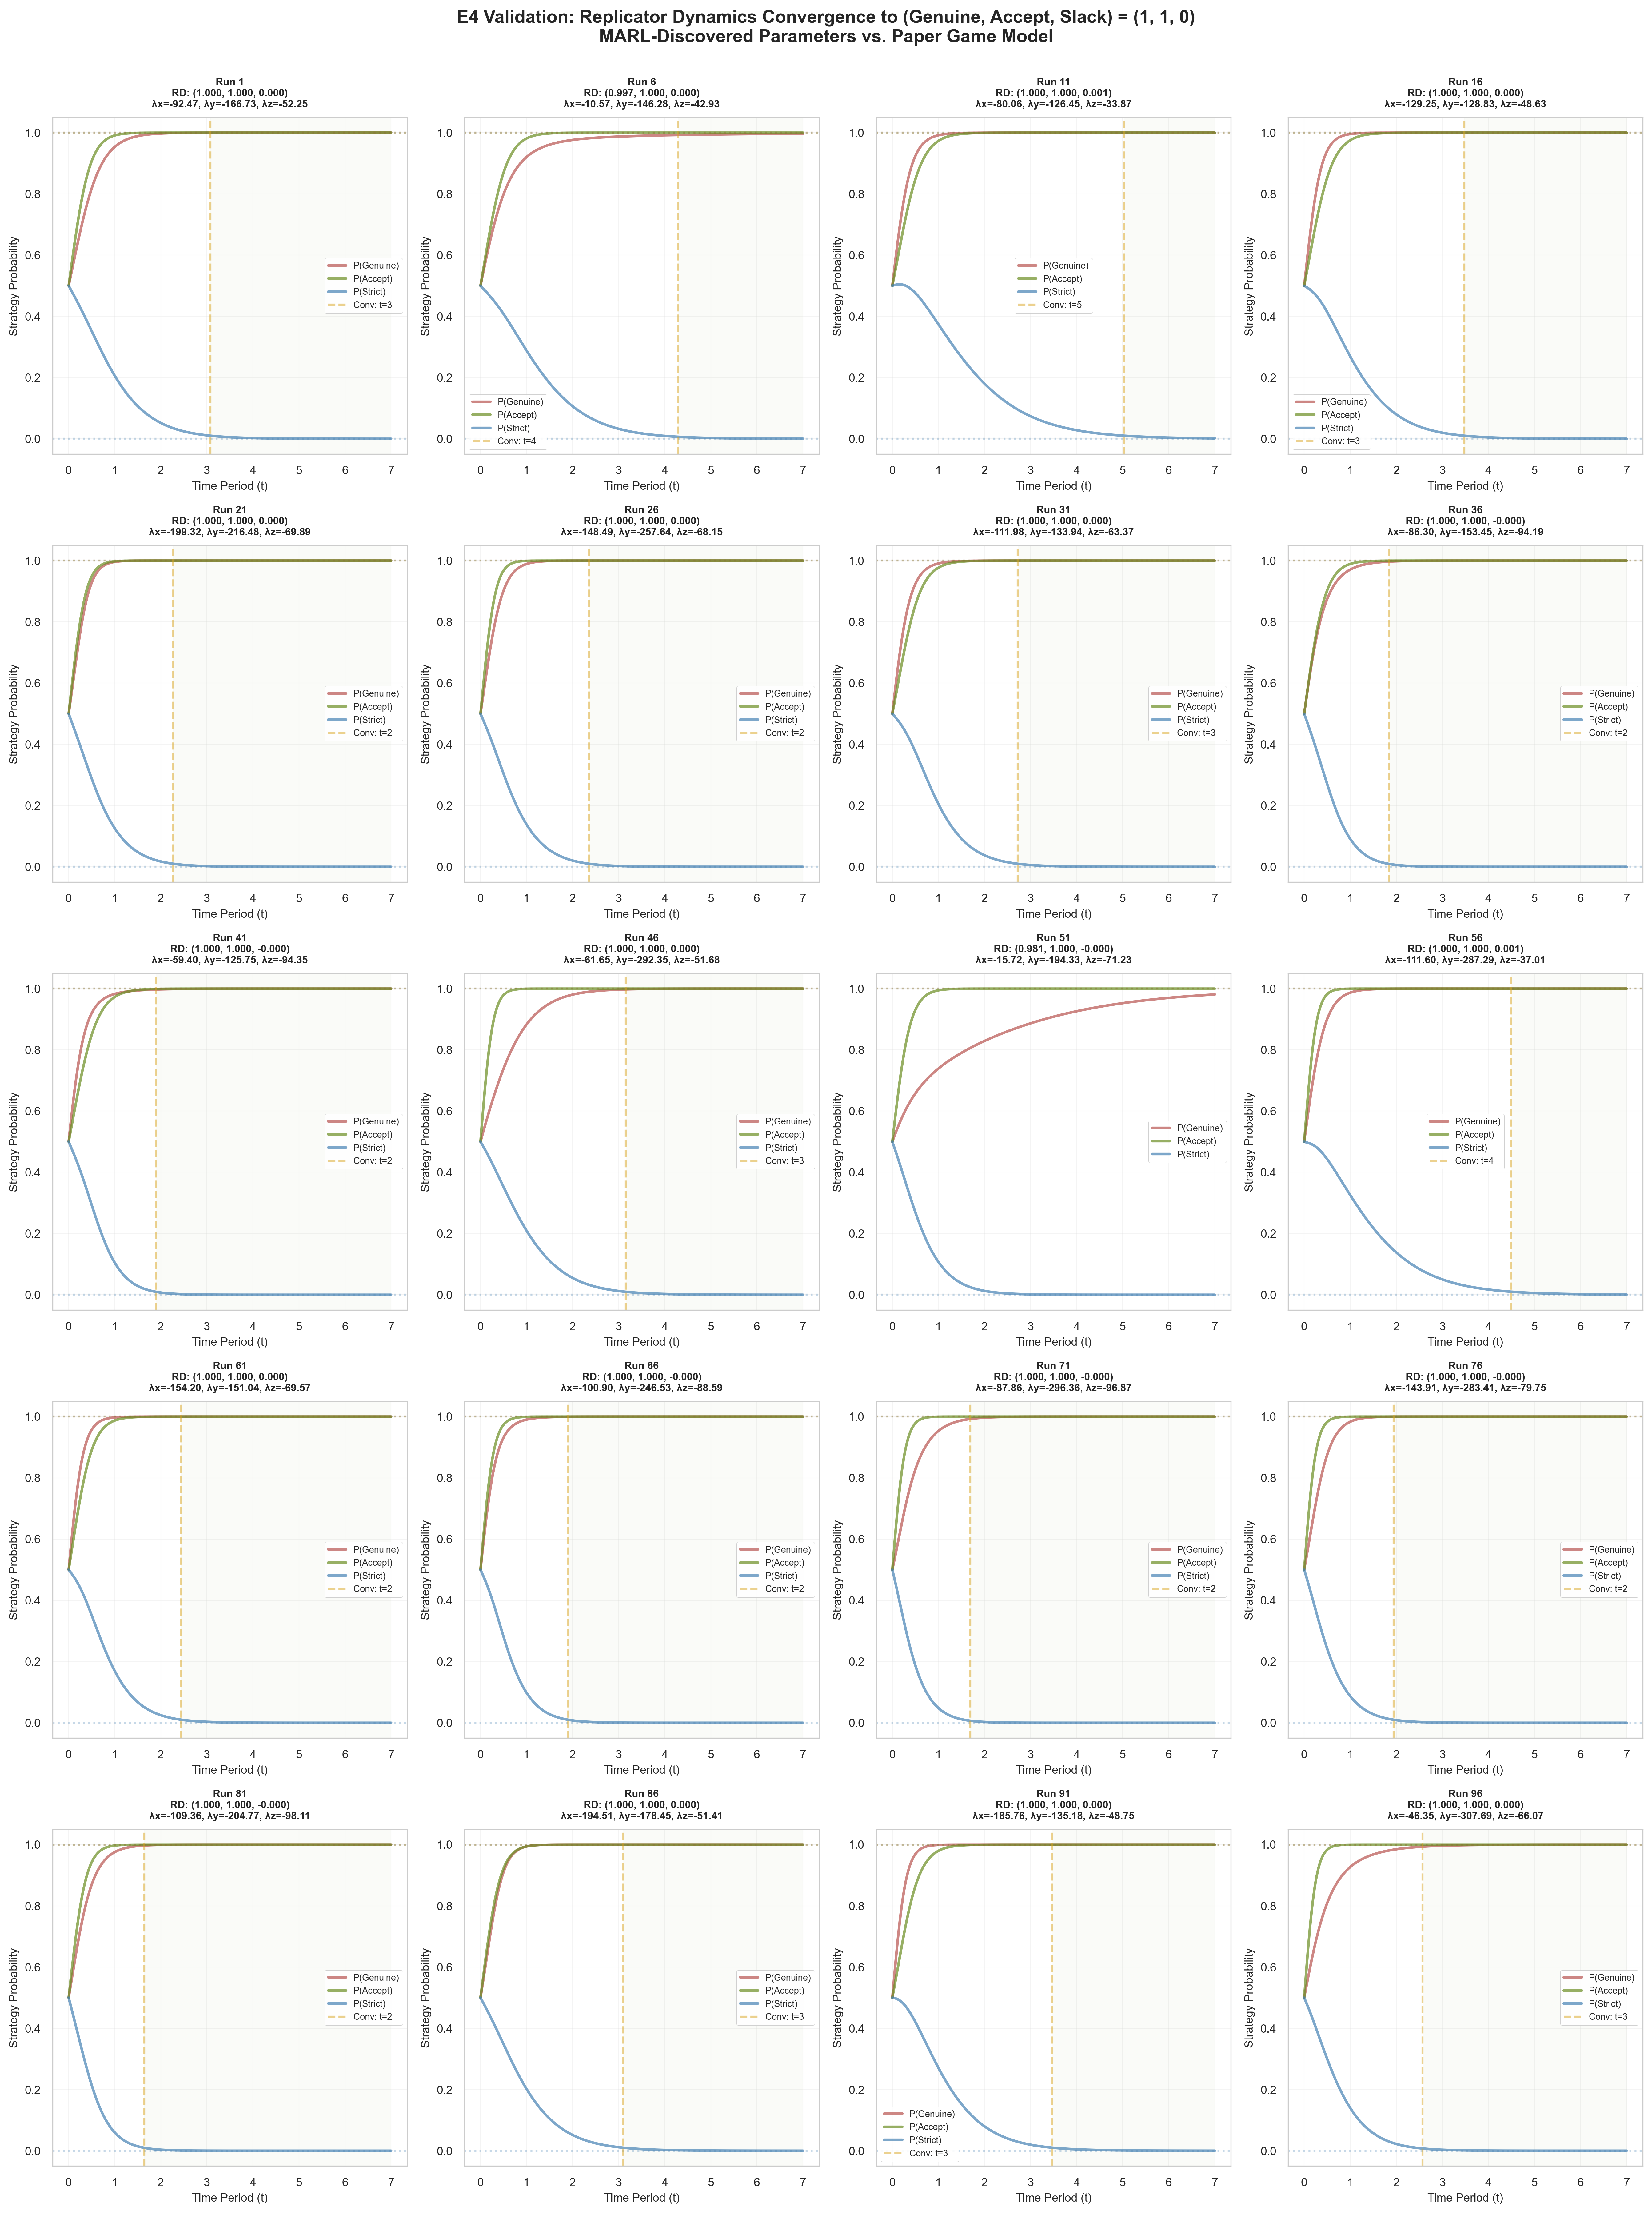

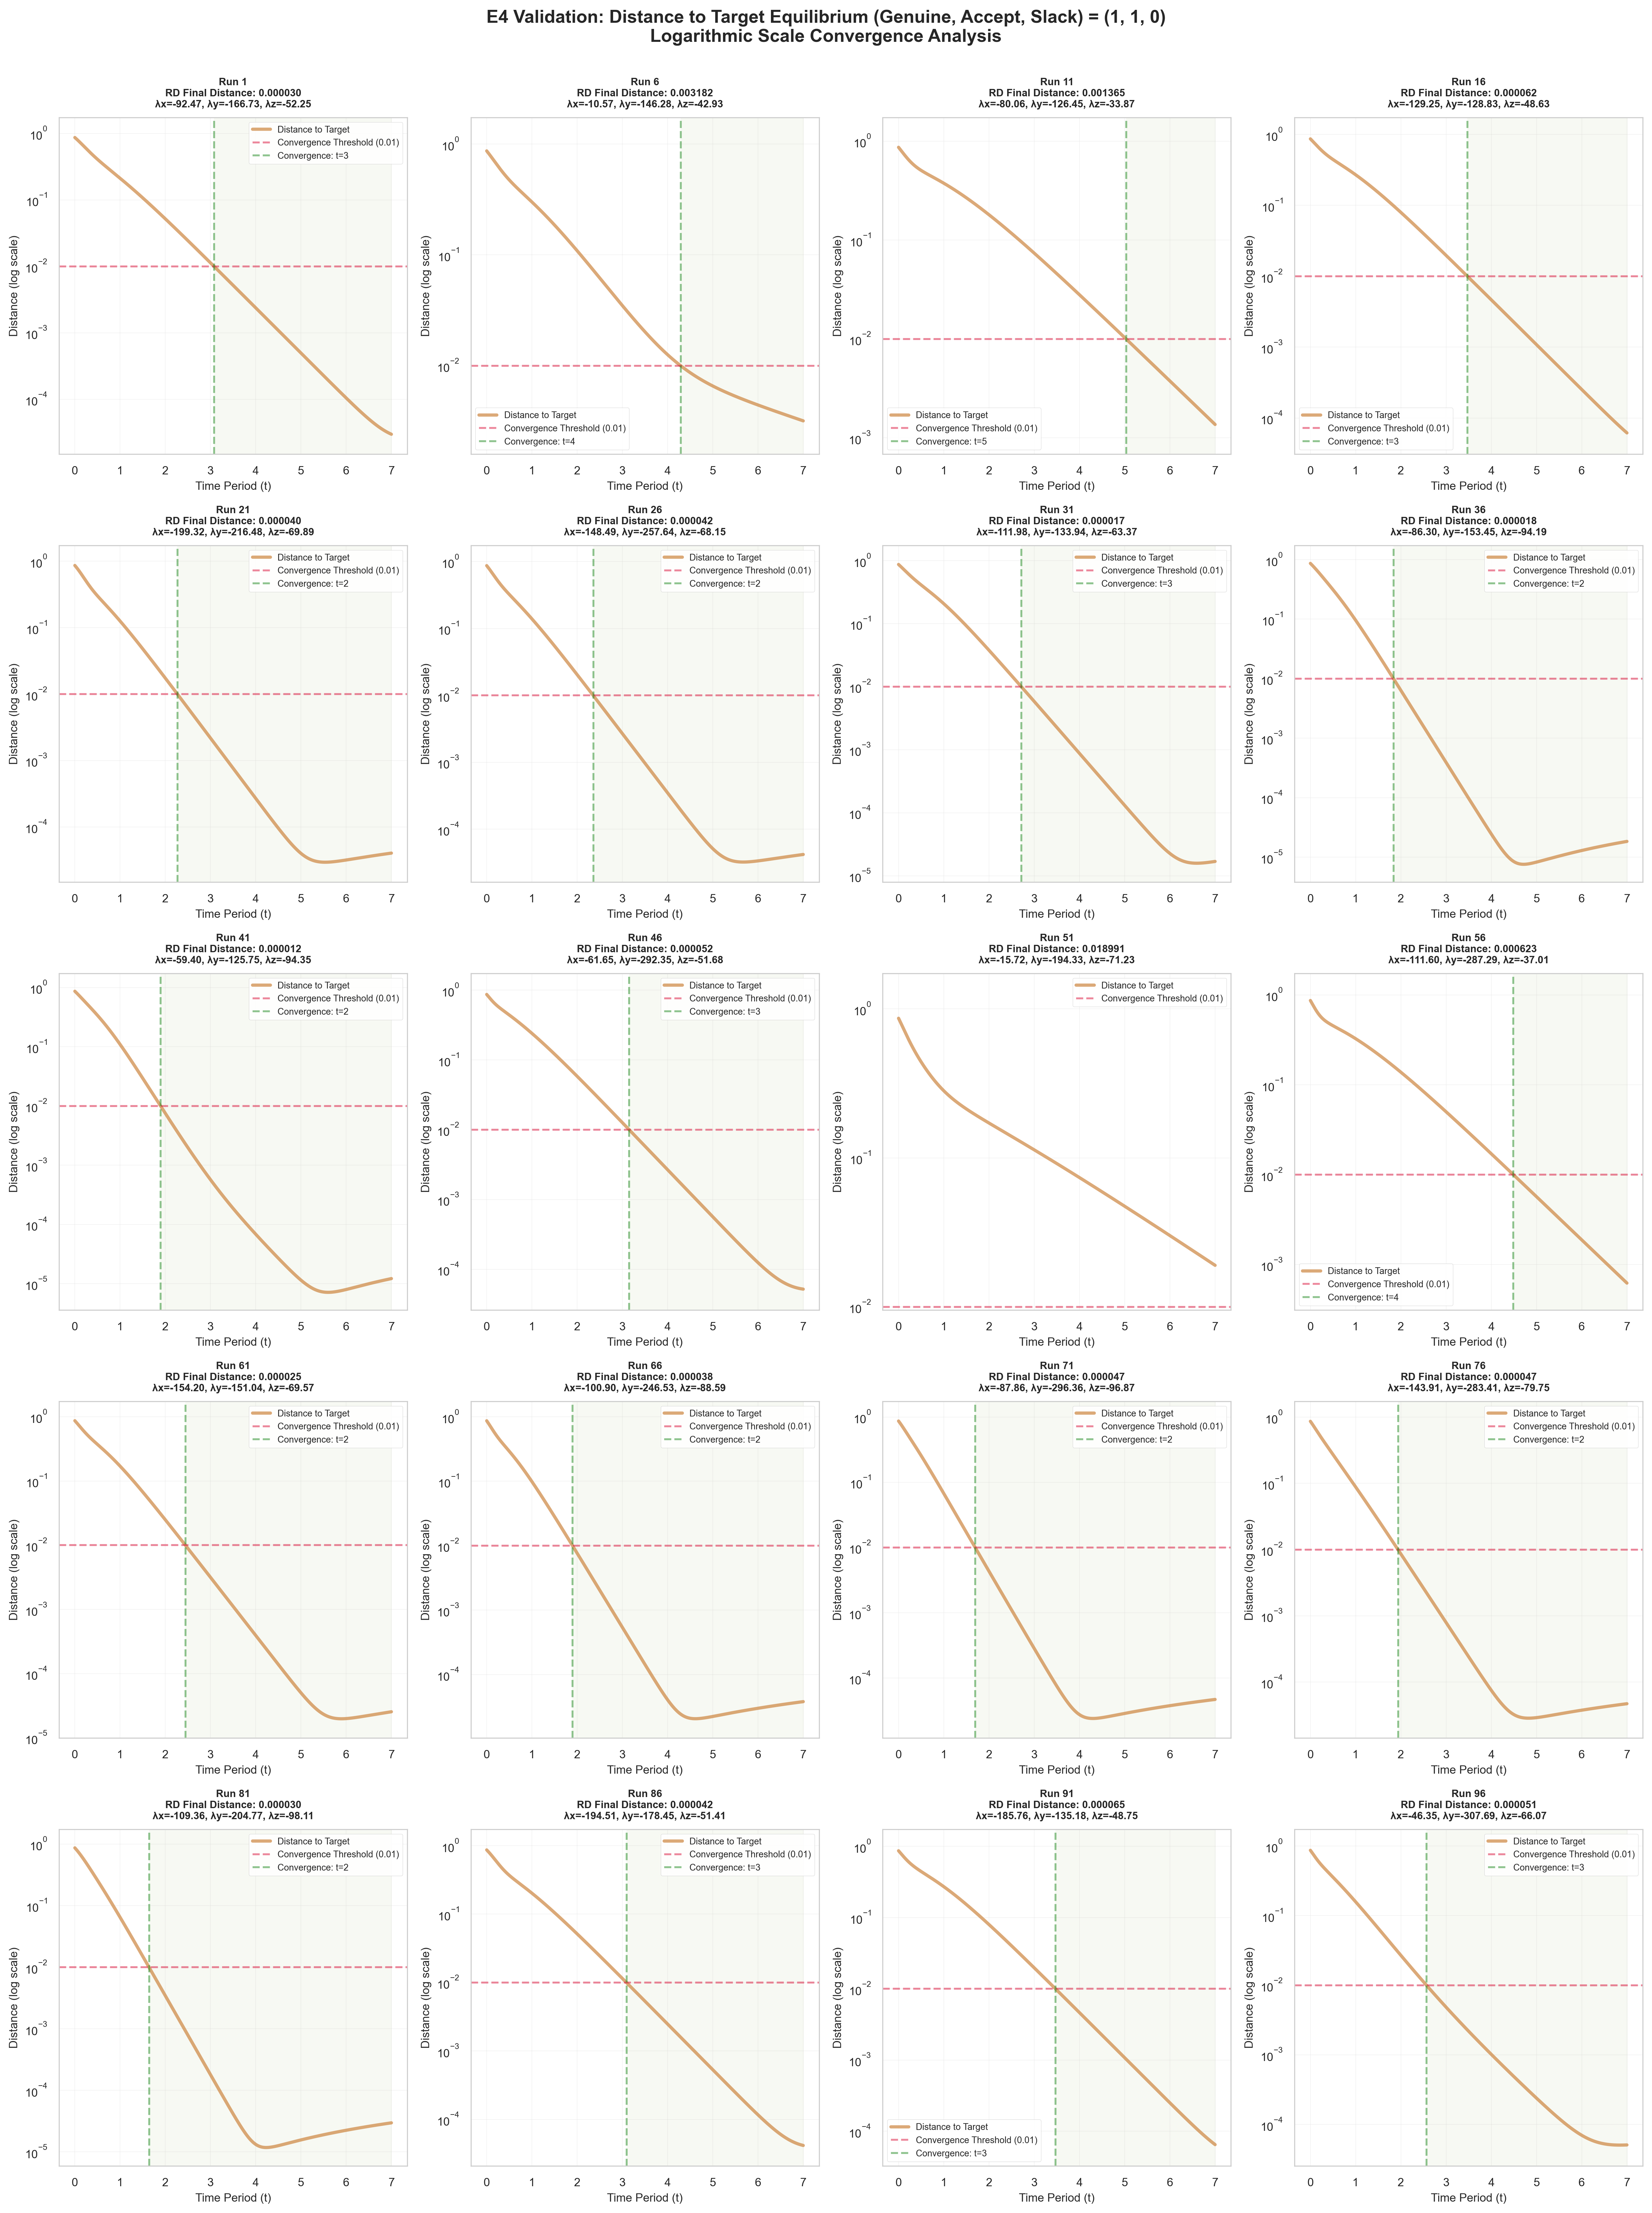

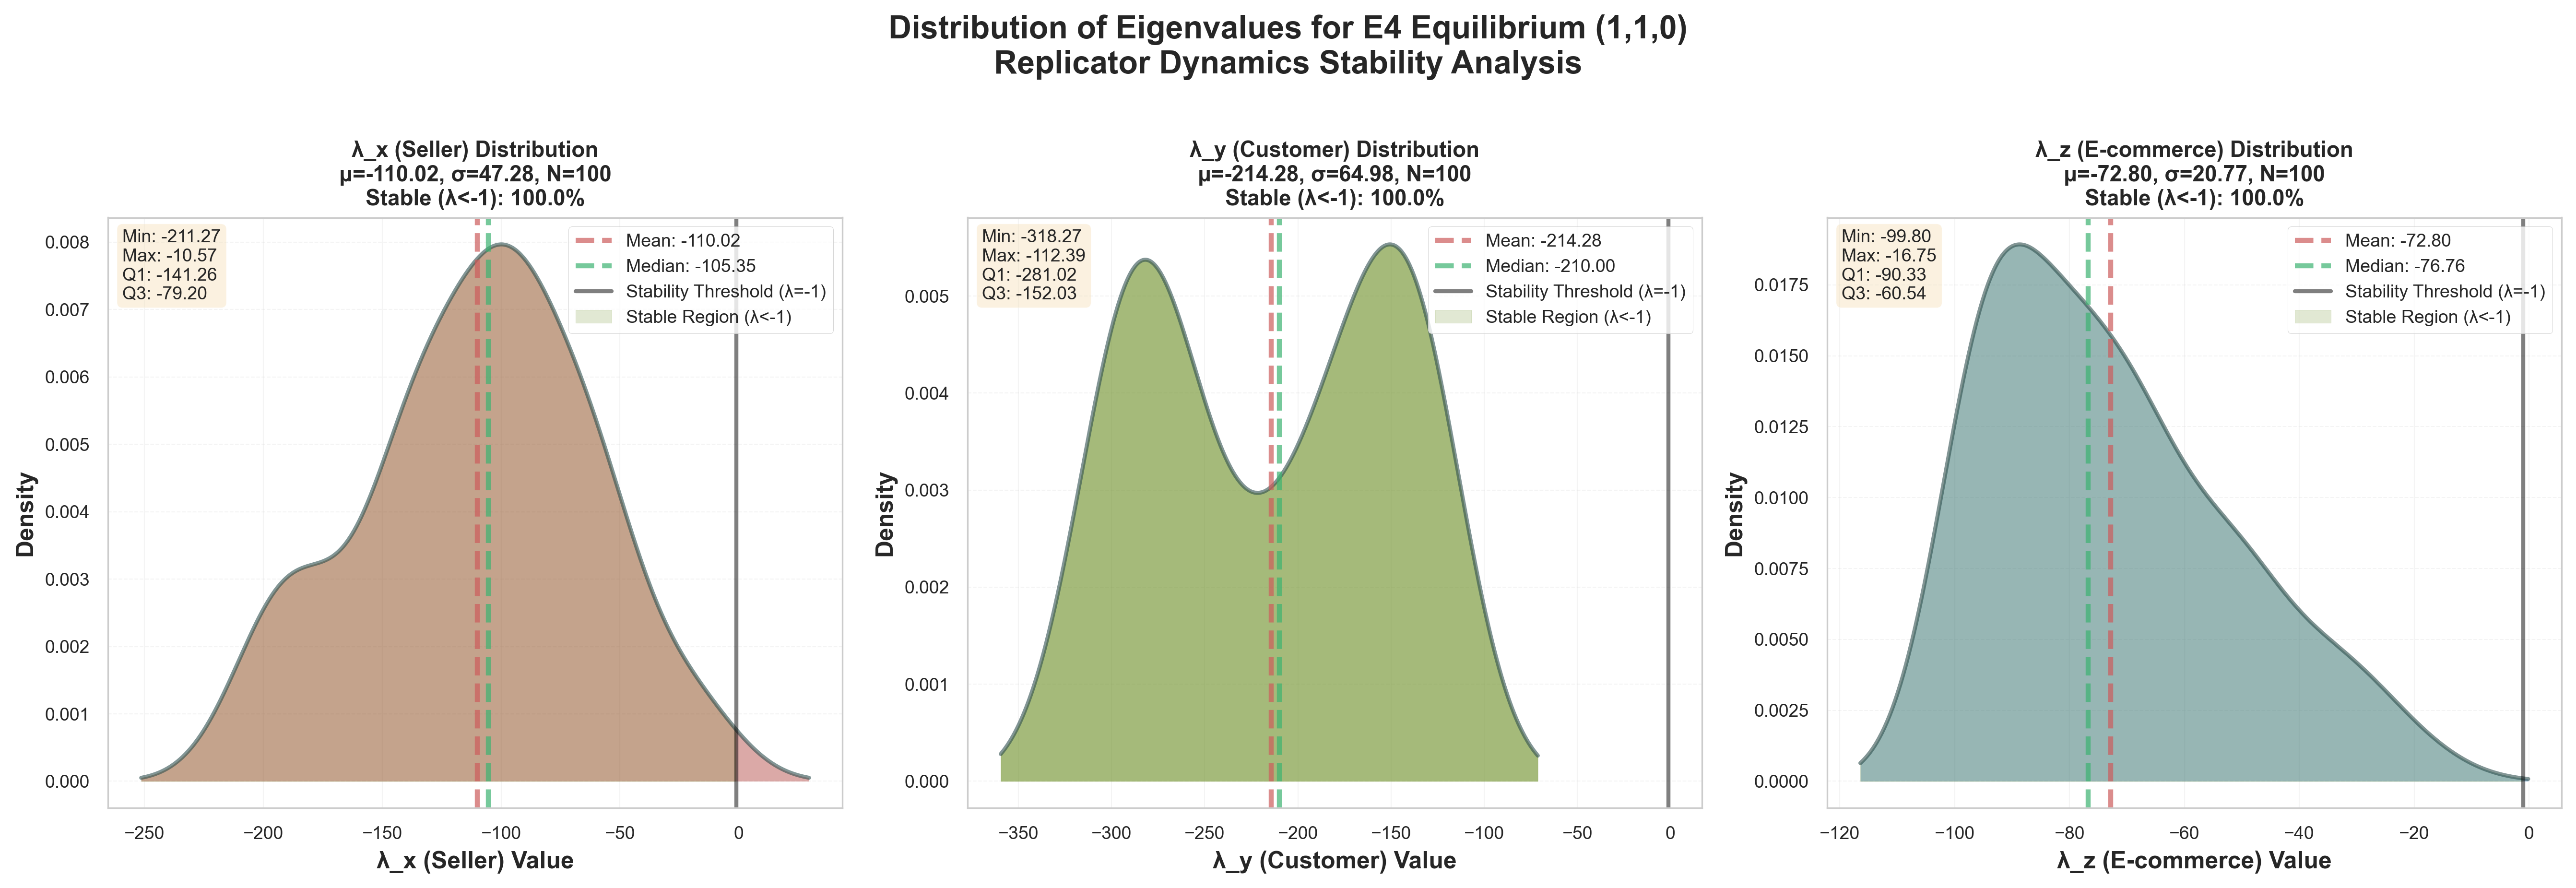

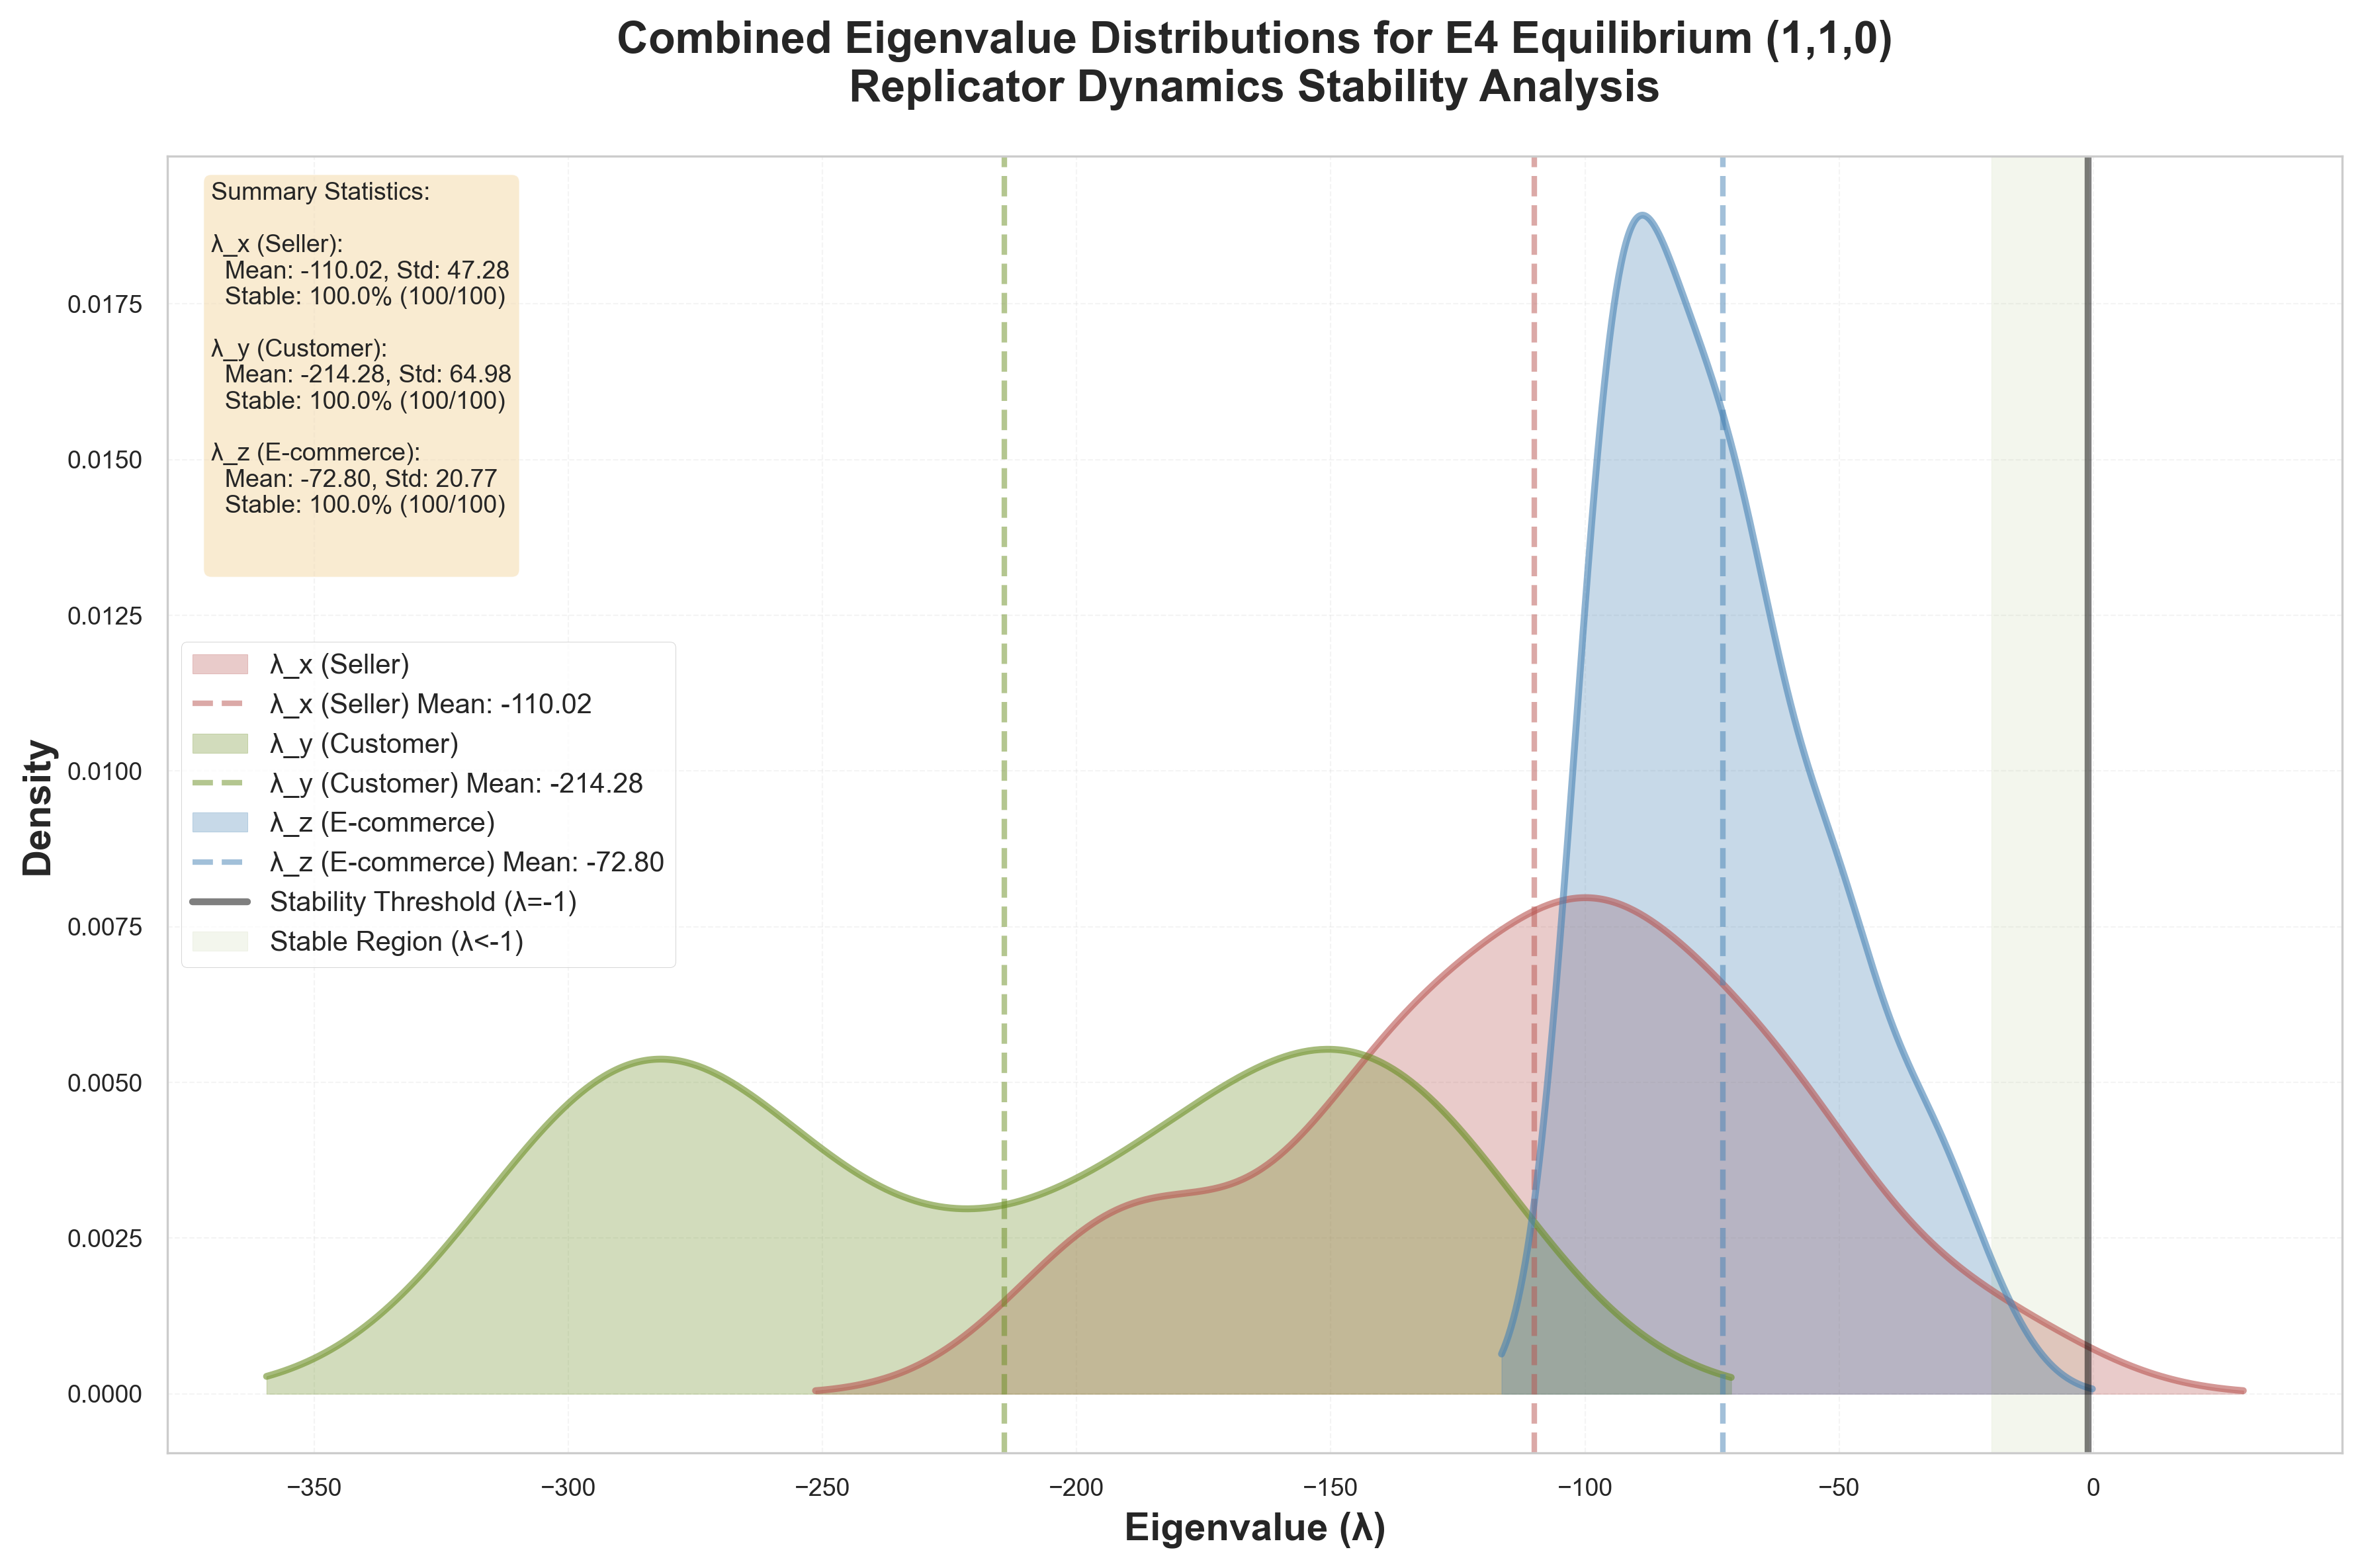


VALIDATION SUMMARY (SIMULATED RUNS)

Run    Stable   RD Conv   RD Time    RD Dist      MARL Dist    λ_x        λ_y        λ_z       
--------------------------------------------------------------------------------------------------------------
1      ✓        ✓         3          0.000030     0.000217     -92.474    -166.731   -52.247   
6      ✓        ✓         4          0.003182     0.000157     -10.574    -146.281   -42.930   
11     ✓        ✓         5          0.001365     0.000544     -80.058    -126.452   -33.868   
16     ✓        ✓         3          0.000062     0.000235     -129.247   -128.825   -48.632   
21     ✓        ✓         2          0.000040     0.000052     -199.321   -216.481   -69.888   
26     ✓        ✓         2          0.000042     0.000073     -148.488   -257.635   -68.150   
31     ✓        ✓         3          0.000017     0.000074     -111.976   -133.939   -63.369   
36     ✓        ✓         2          0.000018     0.000057     -86.299    -153.449 

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import seaborn as sns
from scipy import stats
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Research-quality plot settings with low contrast and eye-soothing colors
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['lines.linewidth'] = 1.8
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.2
plt.rcParams['grid.linewidth'] = 0.5

sns.set_style("whitegrid")
sns.set_palette("colorblind")

print("="*80)
print("E4 VALIDATION: (Genuine, Accept, Slack) = (1, 1, 0)")
print("Replicator Dynamics Convergence Test")
print("="*80)

# Load optimal parameters
csv_path = '(Genuine, Accept Slack)/optimal_parameters.csv'
try:
    df = pd.read_csv(csv_path)
    print(f"\n✓ Loaded {len(df)} parameter sets from MARL optimization")
except FileNotFoundError:
    print(f"\n✗ Error: CSV file not found at {csv_path}")
    print("Please check the file path and try again.")
    exit(1)

print(f"Target equilibrium: Seller P(Genuine)=1, Customer P(Accept)=1, E-commerce P(Strict)=0")

# Game payoff functions (from paper)
def calc_fitness(p, x, y, z):
    """Calculate fitness differentials for each agent"""
    x, y, z = np.clip([x, y, z], 0.0001, 0.9999)
    
    # Seller payoffs (8 strategy combinations)
    PF1 = p['P'] - p['C_m']  # (1,1,1): genuine, accept, strict
    PF2 = p['P'] - p['C_m']  # (1,1,0): genuine, accept, slack
    PF3 = -p['B']  # (1,0,1): genuine, return, strict
    PF4 = -p['B']  # (1,0,0): genuine, return, slack
    
    PF5 = p['alpha']*p['P'] - p['C_m'] - p['F']  # (0,1,1): fake, accept, strict
    PF6 = p['alpha']*p['P'] - p['beta']*p['C_m'] - p['W_m']  # (0,1,0): fake, accept, slack
    PF7 = -p['F'] - p['B']  # (0,0,1): fake, return, strict
    PF8 = -p['B'] - p['F'] - p['I']  # (0,0,0): fake, return, slack
    
    # Customer payoffs
    PC1 = p['R_c']  # (1,1,1)
    PC2 = p['R_c']  # (1,1,0)
    PC3 = -p['C_c']  # (1,0,1)
    PC4 = -p['C_c']  # (1,0,0)
    PC5 = p['R_c']  # (0,1,1) - receives genuine after inspection
    PC6 = p['gamma']*p['R_c']  # (0,1,0) - receives fake
    PC7 = -p['C_c']  # (0,0,1)
    PC8 = p['I'] - p['C_c']  # (0,0,0)
    
    # E-commerce payoffs
    PG1 = p['R_p'] - p['C_p']  # (1,1,1)
    PG2 = p['R_p']  # (1,1,0)
    PG3 = -p['C_p']  # (1,0,1)
    PG4 = -p['C_p']  # (1,0,0)
    PG5 = p['F'] + p['R_p'] - 2*p['C_p']  # (0,1,1)
    PG6 = p['R_p']  # (0,1,0)
    PG7 = p['F'] - 2*p['C_p']  # (0,0,1)
    PG8 = p['F'] - p['C_p']  # (0,0,0)
    
    # Expected payoffs for each strategy
    EGF = z*(y*PF1 + (1-y)*PF3) + (1-z)*(y*PF2 + (1-y)*PF4)  # Genuine
    ENF = z*(y*PF5 + (1-y)*PF7) + (1-z)*(y*PF6 + (1-y)*PF8)  # Fake
    
    EAC = x*(z*PC1 + (1-z)*PC2) + (1-x)*(z*PC5 + (1-z)*PC6)  # Accept
    ERC = x*(z*PC3 + (1-z)*PC4) + (1-x)*(z*PC7 + (1-z)*PC8)  # Return
    
    EST = x*(y*PG1 + (1-y)*PG3) + (1-x)*(y*PG5 + (1-y)*PG7)  # Strict
    ESL = x*(y*PG2 + (1-y)*PG4) + (1-x)*(y*PG6 + (1-y)*PG8)  # Slack
    
    # Fitness differentials (replicator dynamics)
    df_x = EGF - ENF  # Positive means genuine is better than fake
    df_y = EAC - ERC  # Positive means accept is better than return
    df_z = EST - ESL  # Positive means strict is better than slack
    
    return df_x, df_y, df_z

# Replicator dynamics system
def create_system(p, damp=0.03):
    """Create replicator dynamics system"""
    def replicator(t, s):
        x, y, z = np.clip(s, 1e-6, 1-1e-6)
        try:
            dfx, dfy, dfz = calc_fitness(p, x, y, z)
            dx = damp * x * (1-x) * dfx
            dy = damp * y * (1-y) * dfy
            dz = damp * z * (1-z) * dfz
            return [dx, dy, dz] if np.isfinite([dx, dy, dz]).all() else [0, 0, 0]
        except:
            return [0, 0, 0]
    return replicator

# Simplified stability analysis for (1,1,0) equilibrium
def analyze_stability(p, eq):
    """Check stability of equilibrium (1,1,0)"""
    x, y, z = eq
    eigens = []
    stable = True
    
    # For (1,1,0) equilibrium:
    # x=1 (all genuine), y=1 (all accept), z=0 (all slack)
    
    # Check x=1 (all genuine)
    dfx, _, _ = calc_fitness(p, 0.999, y, z)
    if dfx < 0:  # If genuine has lower payoff, fake would invade
        stable = False
    eigens.append(-dfx)
    
    # Check y=1 (all accept)
    _, dfy, _ = calc_fitness(p, x, 0.999, z)
    if dfy < 0:  # If accept has lower payoff, return would invade
        stable = False
    eigens.append(-dfy)
    
    # Check z=0 (all slack)
    _, _, dfz = calc_fitness(p, x, y, 0.001)
    if dfz > 0:  # If strict has higher payoff, it would invade
        stable = False
    eigens.append(dfz)
    
    all_strong = all(e < -1 for e in eigens)
    
    return eigens, stable, all_strong

print("\n" + "="*80)
print("EIGENVALUE CALCULATION PHASE (ALL PARAMETERS)")
print("="*80)

target_eq = (1, 1, 0)  # (P(Genuine)=1, P(Accept)=1, P(Strict)=0)
tmax = 7

print(f"\nCalculating eigenvalues for all {len(df)} parameter sets...")
print(f"Target: P(Genuine)={target_eq[0]}, P(Accept)={target_eq[1]}, P(Strict)={target_eq[2]}")
print("Note: P(Genuine)=1 means all genuine, P(Accept)=1 means all accept, P(Strict)=0 means all slack")

# Calculate eigenvalues for ALL parameters
all_eigenvalues = []

for idx, row in df.iterrows():
    run_id = int(row['run_id'])
    
    params = {
        'P': float(row['P']),
        'C_m': float(row['C_m']),
        'B': float(row['B']),
        'alpha': float(row['alpha']),
        'F': float(row['F']),
        'beta': float(row['beta']),
        'W_m': float(row['W_m']),
        'I': float(row['I']),
        'R_c': float(row['R_c']),
        'C_c': float(row['C_c']),
        'gamma': float(row['gamma']),
        'R_p': float(row['R_p']),
        'C_p': float(row['C_p'])
    }
    
    eigens, stable, all_strong = analyze_stability(params, target_eq)
    
    all_eigenvalues.append({
        'run_id': run_id + 1,
        'lambda_x': eigens[0],
        'lambda_y': eigens[1],
        'lambda_z': eigens[2],
        'stable': stable,
        'all_strong': all_strong
    })
    
    if (run_id + 1) % 20 == 0:
        print(f"  Processed {run_id + 1}/{len(df)} parameter sets...")

print(f"\n✓ Completed eigenvalue calculation for all {len(df)} parameter sets")

# Save eigenvalues to CSV
eigen_df = pd.DataFrame(all_eigenvalues)
eigen_csv_path = 'e4_eigenvalues_all_runs.csv'
eigen_df.to_csv(eigen_csv_path, index=False)
print(f"\n✓ Saved eigenvalues for all runs to: {eigen_csv_path}")

# Calculate and save eigenvalue statistics
lambda_x_vals = eigen_df['lambda_x'].values
lambda_y_vals = eigen_df['lambda_y'].values
lambda_z_vals = eigen_df['lambda_z'].values

stats_data = {
    'eigenvalue': ['lambda_x', 'lambda_y', 'lambda_z'],
    'mean': [np.mean(lambda_x_vals), np.mean(lambda_y_vals), np.mean(lambda_z_vals)],
    'std': [np.std(lambda_x_vals), np.std(lambda_y_vals), np.std(lambda_z_vals)],
    'min': [np.min(lambda_x_vals), np.min(lambda_y_vals), np.min(lambda_z_vals)],
    'max': [np.max(lambda_x_vals), np.max(lambda_y_vals), np.max(lambda_z_vals)],
    'median': [np.median(lambda_x_vals), np.median(lambda_y_vals), np.median(lambda_z_vals)],
    'q25': [np.percentile(lambda_x_vals, 25), np.percentile(lambda_y_vals, 25), np.percentile(lambda_z_vals, 25)],
    'q75': [np.percentile(lambda_x_vals, 75), np.percentile(lambda_y_vals, 75), np.percentile(lambda_z_vals, 75)],
    'stable_count': [sum(eigen_df['stable']), sum(eigen_df['stable']), sum(eigen_df['stable'])],
    'all_strong_count': [sum(eigen_df['all_strong']), sum(eigen_df['all_strong']), sum(eigen_df['all_strong'])]
}

stats_df = pd.DataFrame(stats_data)
stats_csv_path = 'e4_eigenvalues_statistics.csv'
stats_df.to_csv(stats_csv_path, index=False)
print(f"✓ Saved eigenvalue statistics to: {stats_csv_path}")

# Print statistics
print("\n" + "="*80)
print("EIGENVALUE STATISTICS (ALL PARAMETERS)")
print("="*80)
print(f"\n{'Eigenvalue':<12} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Stable':<8}")
print("-"*65)
for i in range(len(stats_df)):
    row = stats_df.iloc[i]
    stable_pct = (row['stable_count'] / len(eigen_df) * 100) if len(eigen_df) > 0 else 0
    print(f"{row['eigenvalue']:<12} {row['mean']:<10.3f} {row['std']:<10.3f} {row['min']:<10.3f} {row['max']:<10.3f} {stable_pct:<8.1f}%")

# Now run SIMULATIONS for specific runs only
print("\n" + "="*80)
print("SIMULATION PHASE (SELECTED RUNS)")
print("="*80)

results = []

# Specific runs to test
specific_runs = [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86, 91, 96]
specific_run_ids = [rn - 1 for rn in specific_runs]
df_test = df[df['run_id'].isin(specific_run_ids)].sort_values('run_id')
n_test = len(df_test)

print(f"\nRunning simulations for {n_test} specific parameter sets: runs {', '.join(map(str, specific_runs))}")

for idx, row in df_test.iterrows():
    run_id = int(row['run_id'])
    
    params = {
        'P': float(row['P']),
        'C_m': float(row['C_m']),
        'B': float(row['B']),
        'alpha': float(row['alpha']),
        'F': float(row['F']),
        'beta': float(row['beta']),
        'W_m': float(row['W_m']),
        'I': float(row['I']),
        'R_c': float(row['R_c']),
        'C_c': float(row['C_c']),
        'gamma': float(row['gamma']),
        'R_p': float(row['R_p']),
        'C_p': float(row['C_p'])
    }
    
    print(f"\nRun {run_id + 1} (ID: {run_id}): MARL distance={row['mean_distance']:.6f}")
    
    # Get eigenvalues from the already calculated data
    eigen_row = eigen_df[eigen_df['run_id'] == run_id + 1].iloc[0]
    eigens = [float(eigen_row['lambda_x']), float(eigen_row['lambda_y']), float(eigen_row['lambda_z'])]
    stable = bool(eigen_row['stable'])
    all_strong = bool(eigen_row['all_strong'])
    
    print(f"  Eigenvalues: {[f'{e:.3f}' for e in eigens]}")
    print(f"  Stable: {'✓ YES' if stable else '✗ NO'}")
    print(f"  All < -1: {'✓ YES' if all_strong else '✗ NO'}")
    
    if not stable:
        print(f"  ⚠ Warning: Equilibrium not stable, skipping simulation...")
        continue
    
    sys = create_system(params)
    sol = solve_ivp(sys, (0, tmax), [0.5, 0.5, 0.5], method='RK45',
                   t_eval=np.linspace(0, tmax, 2000), rtol=1e-9, atol=1e-12)
    
    if sol.success:
        final = sol.y[:, -1]
        dist = np.linalg.norm(final - np.array(target_eq))
        
        dists = [np.linalg.norm(sol.y[:, i] - np.array(target_eq))
                for i in range(len(sol.t))]
        ci = np.where(np.array(dists) < 0.01)[0]
        
        conv = len(ci) > 0
        ctime = sol.t[ci[0]] if conv else tmax
        
        print(f"  Converged: {'✓ YES' if conv else '✗ NO'} (t={ctime:.1f})")
        print(f"  Final distance: {dist:.6f}")
        print(f"  Final state: P(Genuine)={final[0]:.4f}, P(Accept)={final[1]:.4f}, P(Strict)={final[2]:.4f}")
        print(f"  MARL final: P(Genuine)={row['mean_seller_p1']:.4f}, P(Accept)={row['mean_customer_p1']:.4f}, P(Strict)={row['mean_ecommerce_p1']:.4f}")
        
        results.append({
            'run_id': run_id,
            'params': params,
            'eigens': eigens,
            'stable': stable,
            'all_strong': all_strong,
            't': sol.t,
            'x': sol.y[0],
            'y': sol.y[1],
            'z': sol.y[2],
            'conv': conv,
            'ctime': ctime,
            'dist': dist,
            'final': final,
            'marl_dist': float(row['mean_distance']),
            'marl_final': [float(row['mean_seller_p1']), float(row['mean_customer_p1']), float(row['mean_ecommerce_p1'])]
        })
    else:
        print(f"  ✗ Simulation failed")

print(f"\n✓ Completed {len(results)} valid simulations")

# Visualization with eye-soothing colors
print("\n" + "="*80)
print("VISUALIZATION PHASE")
print("="*80)

if len(results) > 0:
    # Eye-soothing color palette
    color_genuine = '#B85450'  # Muted red
    color_accept = '#6B8E23'   # Olive green
    color_strict = '#4682B4'   # Steel blue
    
    # Figure 1: Trajectory plots
    n_plot = len(results)
    nrows = 5
    ncols = 4
    fig1 = plt.figure(figsize=(18, 24))
    fig1.suptitle('E4 Validation: Replicator Dynamics Convergence to (Genuine, Accept, Slack) = (1, 1, 0)\n' +
                  'MARL-Discovered Parameters vs. Paper Game Model',
                  fontsize=14, fontweight='bold', y=0.997)

    for i, r in enumerate(results):
        ax = plt.subplot(nrows, ncols, i+1)
        
        ax.plot(r['t'], r['x'], color=color_genuine, linewidth=2, label='P(Genuine)', alpha=0.7)
        ax.plot(r['t'], r['y'], color=color_accept, linewidth=2, label='P(Accept)', alpha=0.7)
        ax.plot(r['t'], r['z'], color=color_strict, linewidth=2, label='P(Strict)', alpha=0.7)
        
        ax.axhline(1, color=color_genuine, linestyle=':', alpha=0.3, linewidth=1.5)
        ax.axhline(1, color=color_accept, linestyle=':', alpha=0.3, linewidth=1.5)
        ax.axhline(0, color=color_strict, linestyle=':', alpha=0.3, linewidth=1.5)
        
        if r['conv']:
            ax.axvline(r['ctime'], color='#DAA520', linestyle='--', alpha=0.5,
                      linewidth=1.5, label=f'Conv: t={r["ctime"]:.0f}')
            ax.axvspan(r['ctime'], r['t'][-1], alpha=0.03, color='#6B8E23')
        
        ev_str = f"λx={r['eigens'][0]:.2f}, λy={r['eigens'][1]:.2f}, λz={r['eigens'][2]:.2f}"
        final_gen = r['final'][0]
        final_accept = r['final'][1]
        final_strict = r['final'][2]
        
        title = f"Run {r['run_id'] + 1}\n"
        title += f"RD: ({final_gen:.3f}, {final_accept:.3f}, {final_strict:.3f})\n"
        title += f"{ev_str}"
        
        ax.set_title(title, fontsize=8, fontweight='bold', pad=8)
        ax.set_xlabel('Time Period (t)', fontsize=9)
        ax.set_ylabel('Strategy Probability', fontsize=9)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
        ax.legend(fontsize=7, loc='best', framealpha=0.9)

    plt.tight_layout(rect=[0, 0, 1, 0.995])
    plt.savefig('e4_validation_trajectories.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("   ✓ Saved: e4_validation_trajectories.png")
    
    # Figure 2: Distance analysis
    fig2 = plt.figure(figsize=(18, 24))
    fig2.suptitle('E4 Validation: Distance to Target Equilibrium (Genuine, Accept, Slack) = (1, 1, 0)\n' +
                  'Logarithmic Scale Convergence Analysis',
                  fontsize=14, fontweight='bold', y=0.997)

    for i, r in enumerate(results):
        ax = plt.subplot(nrows, ncols, i+1)
        
        dists = [np.linalg.norm(np.array([r['x'][j], r['y'][j], r['z'][j]]) - np.array(target_eq))
                for j in range(len(r['t']))]
        
        ax.semilogy(r['t'], dists, linewidth=2.5, color='#CD853F', alpha=0.7,
                   label='Distance to Target')
        ax.axhline(0.01, color='#DC143C', linestyle='--', alpha=0.5, linewidth=1.5,
                  label='Convergence Threshold (0.01)')
        
        if r['conv']:
            ax.axvline(r['ctime'], color='#228B22', linestyle='--', alpha=0.5,
                      linewidth=1.5, label=f'Convergence: t={r["ctime"]:.0f}')
            ax.axvspan(r['ctime'], r['t'][-1], alpha=0.05, color='#6B8E23')
        
        ev_str = f"λx={r['eigens'][0]:.2f}, λy={r['eigens'][1]:.2f}, λz={r['eigens'][2]:.2f}"
        title = f"Run {r['run_id'] + 1}\n"
        title += f"RD Final Distance: {r['dist']:.6f}\n"
        title += f"{ev_str}"
        
        ax.set_title(title, fontsize=8, fontweight='bold', pad=8)
        ax.set_xlabel('Time Period (t)', fontsize=9)
        ax.set_ylabel('Distance (log scale)', fontsize=9)
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
        ax.legend(fontsize=7, loc='best', framealpha=0.9)
        
        if len(dists) > 0:
            positive_dists = [d for d in dists if d > 0]
            if positive_dists:
                min_dist = min(positive_dists)
                ax.set_ylim(max(min_dist*0.5, 1e-6), max(dists)*2)

    plt.tight_layout(rect=[0, 0, 1, 0.995])
    plt.savefig('e4_validation_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("   ✓ Saved: e4_validation_distance.png")

# Create KDE plots for eigenvalues (using ALL parameter sets)
print("\n" + "="*80)
print("CREATING EIGENVALUE DISTRIBUTION PLOTS (ALL PARAMETERS)")
print("="*80)

# Individual distributions
fig3, axes = plt.subplots(1, 3, figsize=(18, 6))
fig3.suptitle('Distribution of Eigenvalues for E4 Equilibrium (1,1,0)\n' +
              'Replicator Dynamics Stability Analysis',
              fontsize=16, fontweight='bold', y=1.02)

colors = ['#B85450', '#6B8E23', '#4682B4']
eigen_names = ['λ_x (Seller)', 'λ_y (Customer)', 'λ_z (E-commerce)']
eigen_data = [lambda_x_vals, lambda_y_vals, lambda_z_vals]

for i, (ax, data, name, color) in enumerate(zip(axes, eigen_data, eigen_names, colors)):
    if len(data) > 1:
        mean_val = np.mean(data)
        std_val = np.std(data)
        median_val = np.median(data)
        
        try:
            kde = stats.gaussian_kde(data)
            data_min, data_max = np.min(data), np.max(data)
            data_range = data_max - data_min
            x_range = np.linspace(data_min - 0.2*data_range, data_max + 0.2*data_range, 500)
            kde_vals = kde(x_range)
            
            ax.fill_between(x_range, 0, kde_vals, alpha=0.5, color=color, linewidth=0)
            ax.plot(x_range, kde_vals, color='#2F4F4F', linewidth=2, alpha=0.6)
            
            ax.axvline(mean_val, color='#CD5C5C', linestyle='--', 
                      linewidth=2.5, alpha=0.7, label=f'Mean: {mean_val:.2f}')
            ax.axvline(median_val, color='#3CB371', linestyle='--', 
                      linewidth=2.5, alpha=0.7, label=f'Median: {median_val:.2f}')
            ax.axvline(-1, color='#000000', linestyle='-', 
                      linewidth=2, alpha=0.5, label='Stability Threshold (λ=-1)')
            
            stable_region = x_range[x_range < -1]
            if len(stable_region) > 0:
                stable_kde = kde_vals[:len(stable_region)]
                ax.fill_between(stable_region, 0, stable_kde, alpha=0.2, 
                               color='#6B8E23', label='Stable Region (λ<-1)')
        except:
            ax.hist(data, bins=20, color=color, alpha=0.5, edgecolor='black', 
                   linewidth=1.2, density=True)
    
    stable_count = np.sum(data < -1)
    stable_pct = (stable_count / len(data)) * 100 if len(data) > 0 else 0
    
    ax.set_xlabel(f'{name} Value', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    
    title = f'{name} Distribution\n'
    title += f'μ={mean_val:.2f}, σ={std_val:.2f}, N={len(data)}\n'
    title += f'Stable (λ<-1): {stable_pct:.1f}%'
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.2, axis='y', linestyle='--')
    
    stats_text = f'Min: {np.min(data):.2f}\nMax: {np.max(data):.2f}\nQ1: {np.percentile(data, 25):.2f}\nQ3: {np.percentile(data, 75):.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
           fontsize=9, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.tight_layout()
plt.savefig('e4_eigenvalue_distributions.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: e4_eigenvalue_distributions.png")

# Combined KDE plot
fig4, ax = plt.subplots(figsize=(12, 8))

for i, (data, name, color) in enumerate(zip(eigen_data, eigen_names, colors)):
    if len(data) > 1:
        try:
            kde = stats.gaussian_kde(data)
            data_min, data_max = np.min(data), np.max(data)
            data_range = data_max - data_min
            x_range = np.linspace(data_min - 0.2*data_range, data_max + 0.2*data_range, 500)
            kde_vals = kde(x_range)
            
            ax.fill_between(x_range, 0, kde_vals, alpha=0.3, color=color, label=name)
            ax.plot(x_range, kde_vals, color=color, linewidth=2.5, alpha=0.6)
            
            mean_val = np.mean(data)
            ax.axvline(mean_val, color=color, linestyle='--', 
                      linewidth=2, alpha=0.5, label=f'{name} Mean: {mean_val:.2f}')
        except:
            pass

ax.axvline(-1, color='#000000', linestyle='-', 
          linewidth=2.5, alpha=0.5, label='Stability Threshold (λ=-1)')
ax.axvspan(-20, -1, alpha=0.08, color='#6B8E23', label='Stable Region (λ<-1)')

ax.set_xlabel('Eigenvalue (λ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Combined Eigenvalue Distributions for E4 Equilibrium (1,1,0)\n' +
             'Replicator Dynamics Stability Analysis', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.2, linestyle='--')

stats_text = "Summary Statistics:\n\n"
for i, (data, name) in enumerate(zip(eigen_data, eigen_names)):
    if len(data) > 0:
        stable_count = np.sum(data < -1)
        stable_pct = (stable_count / len(data)) * 100
        stats_text += f"{name}:\n"
        stats_text += f"  Mean: {np.mean(data):.2f}, Std: {np.std(data):.2f}\n"
        stats_text += f"  Stable: {stable_pct:.1f}% ({stable_count}/{len(data)})\n\n"

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
       fontsize=9, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig('e4_eigenvalue_distributions_combined.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: e4_eigenvalue_distributions_combined.png")

plt.show()

# Summary statistics
print("\n" + "="*80)
print("VALIDATION SUMMARY (SIMULATED RUNS)")
print("="*80)

if len(results) > 0:
    print(f"\n{'Run':<6} {'Stable':<8} {'RD Conv':<9} {'RD Time':<10} {'RD Dist':<12} {'MARL Dist':<12} "
          f"{'λ_x':<10} {'λ_y':<10} {'λ_z':<10}")
    print("-"*110)

    for r in results:
        ctime_str = f"{r['ctime']:.0f}" if r['conv'] else 'N/A'
        
        print(f"{r['run_id']+1:<6} {'✓' if r['stable'] else '✗':<8} "
              f"{'✓' if r['conv'] else '✗':<9} "
              f"{ctime_str:<10} {r['dist']:<12.6f} {r['marl_dist']:<12.6f} "
              f"{r['eigens'][0]:<10.3f} {r['eigens'][1]:<10.3f} {r['eigens'][2]:<10.3f}")

    stable_count = sum(1 for r in results if r['stable'])
    conv_count = sum(1 for r in results if r['conv'])
    avg_rd_dist = np.mean([r['dist'] for r in results])
    avg_marl_dist = np.mean([r['marl_dist'] for r in results])
    avg_conv_time = np.mean([r['ctime'] for r in results if r['conv']]) if conv_count > 0 else 0
    
    if len(results) > 0:
        lambda_x_mean = np.mean([r['eigens'][0] for r in results])
        lambda_y_mean = np.mean([r['eigens'][1] for r in results])
        lambda_z_mean = np.mean([r['eigens'][2] for r in results])
        lambda_x_std = np.std([r['eigens'][0] for r in results])
        lambda_y_std = np.std([r['eigens'][1] for r in results])
        lambda_z_std = np.std([r['eigens'][2] for r in results])
    
    print("\n" + "="*80)
    print("OVERALL STATISTICS")
    print("="*80)
    print(f"Total parameter sets tested: {len(results)}")
    print(f"Stable equilibrium: {stable_count}/{len(results)} ({100*stable_count/len(results):.1f}%)")
    print(f"Convergence success rate: {conv_count}/{len(results)} ({100*conv_count/len(results):.1f}%)")
    print(f"Average RD final distance: {avg_rd_dist:.6f}")
    print(f"Average MARL distance: {avg_marl_dist:.6f}")
    if conv_count > 0:
        print(f"Average convergence time: {avg_conv_time:.1f} periods")
    
    if len(results) > 0:
        print(f"\nEigenvalue Statistics (simulated runs):")
        print(f"λ_x (Seller): Mean = {lambda_x_mean:.3f}, Std = {lambda_x_std:.3f}")
        print(f"λ_y (Customer): Mean = {lambda_y_mean:.3f}, Std = {lambda_y_std:.3f}")
        print(f"λ_z (E-commerce): Mean = {lambda_z_mean:.3f}, Std = {lambda_z_std:.3f}")
else:
    print("\nNo valid results to summarize.")

print("\n" + "="*80)
print("✓ E4 VALIDATION COMPLETE")
print("="*80)
print("Note: The equilibrium (1,1,0) means:")
print("  - Sellers: P(Genuine)=1 → All sell genuine commodities")
print("  - Customers: P(Accept)=1 → Always accept (don't return)")
print("  - E-commerce: P(Strict)=0 → Always slack (no strict enforcement)")
print(f"\n✓ Eigenvalues calculated and saved for all {len(df)} parameter sets: {eigen_csv_path}")
print(f"✓ Eigenvalue statistics saved to: {stats_csv_path}")
print(f"✓ Replicator dynamics simulations run for {len(results)} selected parameter sets")
print("✓ All visualizations saved as PNG files")

In [7]:
from PIL import Image

# Load images
images = [
    Image.open(f"(Genuine, Accept Slack)\\convergence_run_{i}.png")
    if i < 100 else Image.open("(Genuine, Accept Slack)\\convergence_run_100.png")
    for i in range(1, 102, 5)
]

# Crop from top-left
def crop_top_left(img, w, h):
    return img.crop((0, 0, w, h))

W, H = 2200, 640
images = [crop_top_left(img, W, H) for img in images]

# ---- Step 1: Horizontal merge (pairs) ----
horizontal_pairs = []

for i in range(0, len(images), 2):
    merged = Image.new("RGB", (W * 2, H))

    merged.paste(images[i], (0, 0))
    if i + 1 < len(images):          # safe for odd count
        merged.paste(images[i + 1], (W, 0))

    horizontal_pairs.append(merged)

# ---- Step 2: Vertical merge (4 rows, KEEP leftovers) ----
rows_per_image = 5

for i in range(0, len(horizontal_pairs), rows_per_image):
    chunk = horizontal_pairs[i:i + rows_per_image]

    merged_v = Image.new(
        "RGB",
        (W * 2, H * len(chunk))   # dynamic height
    )

    for j, img in enumerate(chunk):
        merged_v.paste(img, (0, j * H))

    merged_v.save(
        f"merged_grid_{i//rows_per_image + 1} (Genuine, Accept, Slack).png"
    )
